# Previsão de Inadimplência Bancária via Regressão Logística

**Disciplina:** Otimização Não-Linear 
**Professor:** Felipe Garcia 
**Integrantes:** Gabriel Negreiros Saraiva, Júlia Moraes da Silva, Luiz Eduardo de Almeida Siqueira Silva, Paulo Victor Cordeiro Rufino de Araújo, Pedro Lucas Simões Cabral

---

## 1. Objetivo

Implementar um classificador de **Regressão Logística** para prever inadimplência bancária, formulando o treinamento como um **problema de otimização** em aprendizado supervisionado de classificação.

$$\min_{\theta} \; L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

onde $\hat{y}_i = \sigma(x_i^\top \theta)$ e $\sigma(z) = \frac{1}{1 + e^{-z}}$.

Serão comparados dois algoritmos de otimização:
- **Gradiente Descendente** com busca em linha
- **Método de Newton** com busca em linha

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

---
## 2. Carregamento e Pré-processamento dos Dados

Dataset: **Credito** — 10.128 clientes, 15 features financeiras e comportamentais, rótulo binário de inadimplência.

In [120]:
df = pd.read_csv('../ONL/dados/credito.csv', na_values=['na', '','NaN','NA','NAN'])

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 2. Corrigir colunas numéricas com formato BR (ponto=milhar, vírgula=decimal)
df['limite_credito'] = (df['limite_credito']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))

df['valor_transacoes_12m'] = (df['valor_transacoes_12m']
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float))

# 3. Remover coluna id (não agrega ao modelo)
df = df.drop(columns=['id'])

# 4. Separar X e y
X = df.drop(columns=['default'])
y = df['default']

# 5. One Hot Encoding (drop_first=True para evitar multicolinearidade)
colunas_categoricas = ['sexo', 'escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao']
X = pd.get_dummies(X, columns=colunas_categoricas, drop_first=True)

# 6. Split treino/teste (stratify mantém proporção de inadimplentes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Escalar features numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [122]:
X.columns

Index(['idade', 'dependentes', 'meses_de_relacionamento', 'qtd_produtos',
       'iteracoes_12m', 'meses_inativo_12m', 'limite_credito',
       'valor_transacoes_12m', 'qtd_transacoes_12m', 'sexo_M',
       'escolaridade_ensino medio', 'escolaridade_graduacao',
       'escolaridade_mestrado', 'escolaridade_sem educacao formal',
       'estado_civil_divorciado', 'estado_civil_solteiro',
       'salario_anual_$40K - $60K', 'salario_anual_$60K - $80K',
       'salario_anual_$80K - $120K', 'salario_anual_menos que $40K',
       'tipo_cartao_gold', 'tipo_cartao_platinum', 'tipo_cartao_silver'],
      dtype='object')

---
## 3. Formulação Matemática

### Modelo

Dado $X \in \mathbb{R}^{n \times (p+1)}$ (com coluna de bias), $y \in \{0,1\}^n$, $\theta \in \mathbb{R}^{p+1}$:

$$\hat{y}_i = \sigma(x_i^\top \theta), \quad \sigma(z) = \frac{1}{1 + e^{-z}}$$

### Função de Perda (a minimizar)

$$L(\theta) = -\sum_{i=1}^{n} \left[ y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \right]$$

### Gradiente

$$\nabla L(\theta) = X^\top(\hat{y} - y)$$

### Hessiana

$$H(\theta) = X^\top W X, \quad W = \mathrm{diag}\!\left(\hat{y}_i(1-\hat{y}_i)\right)$$

A Hessiana é **positiva semi-definida** → $L(\theta)$ é **convexa** → qualquer mínimo local é global.

---
## 3.1 Gradiente, Hessiana e Prova de Convexidade

### Prova: H(θ) é Positiva Semi-Definida

A Hessiana da função de perda (sem regularização) é:

$$H(\theta) = \frac{1}{n} X^\top W X, \qquad W = \mathrm{diag}\!\left(\hat{y}_i(1-\hat{y}_i)\right)$$

**Prova algébrica** — Para qualquer $v \in \mathbb{R}^{p+1}$:

$$v^\top H v = \frac{1}{n}\, v^\top X^\top W X v = \frac{1}{n}\,(Xv)^\top W (Xv) = \frac{1}{n}\sum_{i=1}^{n} w_i\,(x_i^\top v)^2$$

Como $\sigma(z) \in (0,1)$ para todo $z$ real, cada peso satisfaz:

$$w_i = \hat{y}_i(1 - \hat{y}_i) \in \left(0,\, \tfrac{1}{4}\right]$$

Logo cada termo $w_i\,(x_i^\top v)^2 \geq 0$, e portanto:

$$\boxed{v^\top H v \geq 0 \quad \forall\, v \quad \Longrightarrow \quad H(\theta) \succeq 0 \quad \forall\, \theta}$$

> **Com regularização L2** ($\lambda > 0$): a implementação usa $H_{\text{reg}} = H + \lambda\,\mathrm{diag}(0, 1, \ldots, 1)$, que adiciona $\lambda > 0$ a todos os autovalores (exceto o do bias). Isso torna $H_{\text{reg}}$ **estritamente positiva definida** ($H \succ 0$), garantindo unicidade do mínimo e estabilidade numérica ao resolver $H\,d = -\nabla L$ no Método de Newton.

In [123]:
from regressao_log import RegressaoLogistica

# Preparar dados: converter para numpy e adicionar coluna de bias
X_np = np.array(X_train, dtype=float)
y_np = np.array(y_train, dtype=float)
X_b  = np.c_[np.ones(X_np.shape[0]), X_np]   # (n, p+1)

theta_0 = np.zeros(X_b.shape[1])
lambda_ = 0.01

# ---------- Gradiente em θ₀ = 0 ----------
grad_0 = RegressaoLogistica._gradiente(theta_0, X_b, y_np, lambda_)

# ---------- Hessiana em θ₀ = 0 ----------
H_0 = RegressaoLogistica._hessiana(theta_0, X_b, lambda_)

# ---------- Autovalores (eigvalsh para matrizes simétricas) ----------
autovalores = np.linalg.eigvalsh(H_0)

print(f"Dimensão de H(θ₀):            {H_0.shape}")
print(f"‖∇L(θ₀)‖:                     {np.linalg.norm(grad_0):.4f}")
print(f"Autovalor mínimo λ_min:        {autovalores.min():.8f}  "
      f"{'≥ 0  →  PSD ✓' if autovalores.min() >= -1e-10 else '< 0  ✗'}")
print(f"Autovalor máximo λ_max:        {autovalores.max():.4f}")
print(f"Número de condição κ(H):       {autovalores.max() / max(autovalores.min(), 1e-12):.1f}")
print(f"\nTodos autovalores ≥ 0?        {'Sim ✓' if (autovalores >= -1e-10).all() else 'Não ✗'}")

Dimensão de H(θ₀):            (24, 24)
‖∇L(θ₀)‖:                     3442.9483
Autovalor mínimo λ_min:        0.00294004  ≥ 0  →  PSD ✓
Autovalor máximo λ_max:        42136641.5920
Número de condição κ(H):       14331987083.8

Todos autovalores ≥ 0?        Sim ✓


In [124]:
nomes_features = ["bias"] + list(X_train.columns)

### O que implica H(θ) ⪰ 0?

#### 1. L(θ) é convexa

Uma função diferenciável é convexa se e somente se sua Hessiana é positiva semi-definida em todo o domínio. Como $H(\theta) \succeq 0$ para **qualquer** $\theta$ (os pesos $w_i = \hat{y}_i(1-\hat{y}_i)$ dependem de $\theta$, mas sempre $w_i > 0$), a função de perda de entropia cruzada é **globalmente convexa**.

**Consequência prática:** qualquer mínimo local é automaticamente um mínimo global. O algoritmo de otimização não pode ficar preso em ótimos locais — qualquer convergência é para a solução ótima.

#### 2. O Método de Newton é garantidamente uma direção de descida

A direção de Newton $d_k = -H(\theta_k)^{-1} \nabla L(\theta_k)$ é uma **direção de descida** sempre que $H \succ 0$:

$$\nabla L^\top d_k = -\nabla L^\top H^{-1} \nabla L < 0$$

pois $H^{-1} \succ 0$ quando $H \succ 0$. Isso garante que cada passo de Newton reduz $L(\theta)$.

#### 3. O número de condição κ(H) governa a velocidade do GD

O Gradiente Descendente converge em $O(\kappa(H))$ iterações no pior caso, onde:

$$\kappa(H) = \frac{\lambda_{\max}}{\lambda_{\min}}$$

Um $\kappa$ alto significa que existem direções com curvaturas muito diferentes — o GD "ziguezagueia" entre elas. O Método de Newton usa $H^{-1}$ para normalizar essas curvaturas, sendo **invariante ao condicionamento** de $H$ e convergindo em $O(\log(1/\varepsilon))$ iterações independentemente de $\kappa$.

---
## 4. Demonstração das Funções do Modelo

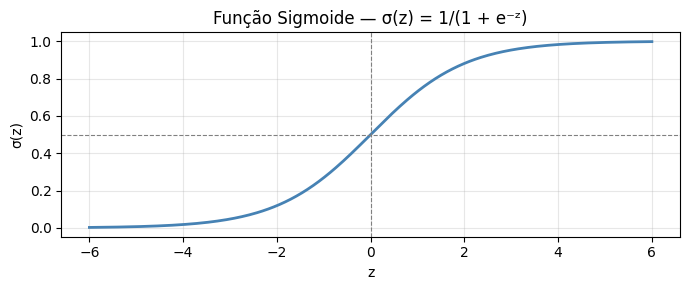

Perda inicial L(0):          0.69
‖∇L(0)‖:                     3442.95
Autovalor mínimo H(0):       0.0029  (≥ 0 → convexa ✓)
Autovalor máximo H(0):       42136641.5920
Número de condição H(0):     14331987083.8


In [125]:
# Sigmoide
z = np.linspace(-6, 6, 300)
plt.figure(figsize=(7, 3))
plt.plot(z, RegressaoLogistica._sigmoide(z), color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0,   color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.title('Função Sigmoide — σ(z) = 1/(1 + e⁻ᶻ)')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Perda, gradiente e hessiana no ponto inicial (usando variáveis da seção 3.1)
perda_0 = RegressaoLogistica._funcao_perda(theta_0, X_b, y_np, lambda_)

print(f"Perda inicial L(0):          {perda_0:.2f}")
print(f"‖∇L(0)‖:                     {np.linalg.norm(grad_0):.2f}")
print(f"Autovalor mínimo H(0):       {autovalores.min():.4f}  (≥ 0 → convexa ✓)")
print(f"Autovalor máximo H(0):       {autovalores.max():.4f}")
print(f"Número de condição H(0):     {autovalores.max()/autovalores.min():.1f}")

---
## 5. Métodos de Busca em Linha — Demonstração 1D

Aplicamos cada método à função $f(\alpha) = 2\alpha^2 - 7\alpha + 1$, cujo mínimo exato é $\alpha^* = 7/4 = 1{,}75$.

intervalo_inicial:          [0.6400, 2.5600]
busca_secao_aurea:          α* = 1.75000000  (erro = 2.82e-10)
busca_particao_igual:       α* = 1.75000018  (erro = 1.79e-07)
busca_ajuste_quadratico:    α* = 1.75000000  (erro = 6.66e-16)


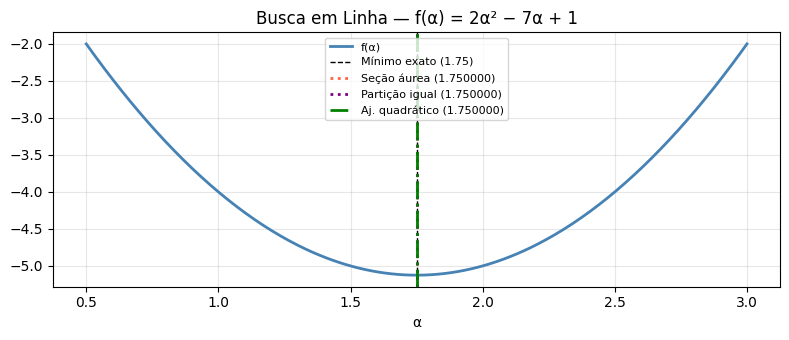

In [126]:
f = lambda a: 2*a**2 - 7*a + 1
alpha_exato = 1.75

# Intervalo inicial automático
a0, b0 = RegressaoLogistica._intervalo_inicial(f)
print(f"intervalo_inicial:          [{a0:.4f}, {b0:.4f}]")

# Seção áurea
alpha_aurea = RegressaoLogistica._busca_secao_aurea(f, a0, b0, n_iter=50)
print(f"busca_secao_aurea:          α* = {alpha_aurea:.8f}  (erro = {abs(alpha_aurea-alpha_exato):.2e})")

# Partição igual (trisseção)
alpha_part = RegressaoLogistica._busca_particao_igual(f, a0, b0, tol=1e-6)
print(f"busca_particao_igual:       α* = {alpha_part:.8f}  (erro = {abs(alpha_part-alpha_exato):.2e})")

# Ajuste quadrático
alpha_quad = RegressaoLogistica._busca_ajuste_quadratico(f, a0, b0, n_iter=50)
print(f"busca_ajuste_quadratico:    α* = {alpha_quad:.8f}  (erro = {abs(alpha_quad-alpha_exato):.2e})")

# Visualização
alpha_vals = np.linspace(0.5, 3.0, 300)
plt.figure(figsize=(8, 3.5))
plt.plot(alpha_vals, f(alpha_vals), color='steelblue', linewidth=2, label='f(α)')
plt.axvline(alpha_exato,  color='black',  linestyle='--', linewidth=1, label=f'Mínimo exato ({alpha_exato})')
plt.axvline(alpha_aurea,  color='tomato', linestyle=':',  linewidth=2, label=f'Seção áurea ({alpha_aurea:.6f})')
plt.axvline(alpha_part,   color='purple', linestyle=':',  linewidth=2, label=f'Partição igual ({alpha_part:.6f})')
plt.axvline(alpha_quad,   color='green',  linestyle='-.',  linewidth=2, label=f'Aj. quadrático ({alpha_quad:.6f})')
plt.xlabel('α'); plt.title('Busca em Linha — f(α) = 2α² − 7α + 1')
plt.legend(fontsize=8); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Criando treino com balanceamento para testes

In [127]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

---
## 6. Treinamento — Gradiente Descendente com Busca em Linha

$$\theta_{k+1} = \theta_k - \alpha^* \nabla L(\theta_k), \quad \alpha^* = \arg\min_\alpha L(\theta_k - \alpha \nabla L(\theta_k))$$

**Nota:** O GD tem convergência **linear** — a norma do gradiente decresce ~0.5% por iteração perto do ótimo. Com 24.000 amostras, atingir $\|\nabla L\| < 10^{-4}$ requer ~7.800 iterações. Aqui executamos 500 iterações para demonstrar a trajetória de convergência.

Executando Gradiente Descendente (500 iterações)...
Iterações executadas:  500
Perda inicial → final: 0.69 → 0.42
‖∇L‖ inicial → final:  3442.95 → 6.5235
Tempo de execução:     16.2s


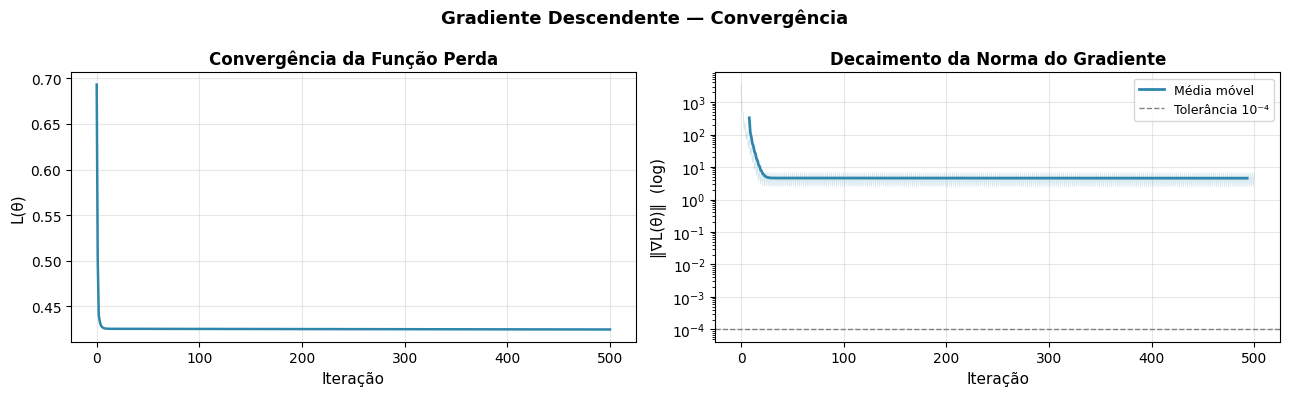

In [128]:
import time

# Criar modelo com Gradiente Descendente
modelo_gd = RegressaoLogistica(
    metodo_otimizacao='gradiente_descendente',
    metodo_busca='secao_aurea',
    tmax=500,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Gradiente Descendente (500 iterações)...")
t_inicio_gd = time.time()
modelo_gd.fit(X_train, y_train)
tempo_gd = time.time() - t_inicio_gd

print(f"Iterações executadas:  {modelo_gd.n_iteracoes_}")
print(f"Perda inicial → final: {modelo_gd.historico_perda_[0]:.2f} → {modelo_gd.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:  {modelo_gd.historico_norma_grad_[0]:.2f} → {modelo_gd.historico_norma_grad_[-1]:.4f}")
print(f"Tempo de execução:     {tempo_gd:.1f}s")

# Gráfico de convergência
cor = '#2E86AB'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Painel esquerdo: Perda
axes[0].plot(modelo_gd.historico_perda_, color=cor, linewidth=1.8)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Painel direito: Norma do gradiente (log) com média móvel
n_grad = len(modelo_gd.historico_norma_grad_)
janela = max(5, n_grad // 30)
mm = np.convolve(modelo_gd.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
x_mm = range(janela//2, janela//2 + len(mm))
axes[1].semilogy(range(n_grad), modelo_gd.historico_norma_grad_, color=cor, linewidth=0.6, alpha=0.2)
axes[1].semilogy(x_mm, mm, color=cor, linewidth=2.0, label='Média móvel')
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Gradiente Descendente — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6.1 Com balanceamento

Executando Gradiente Descendente (500 iterações)...
Iterações executadas:  500
Perda inicial → final: 0.69 → 0.67
‖∇L‖ inicial → final:  458.42 → 4.7393
Tempo de execução:     27.2s


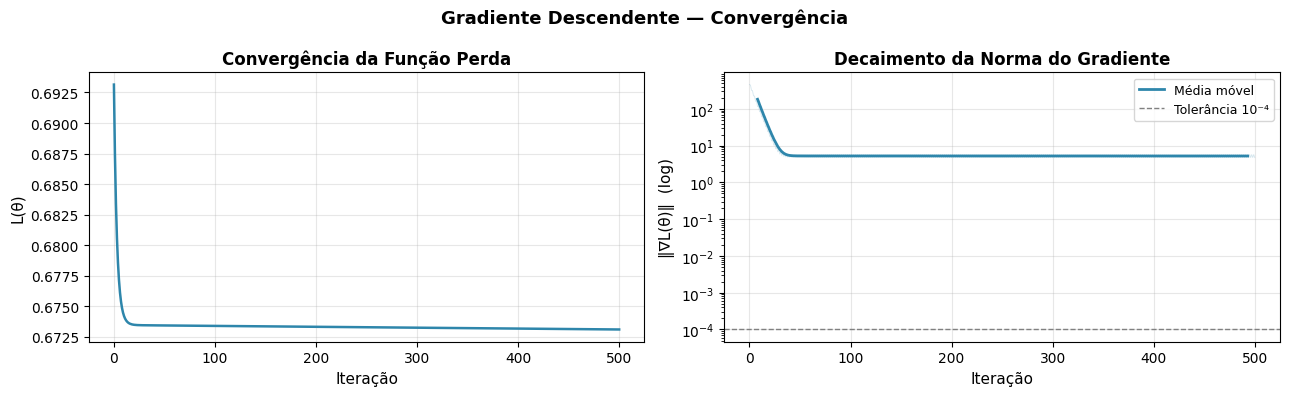

In [129]:
# Criar modelo com Gradiente Descendente
modelo_gd_balanced = RegressaoLogistica(
    metodo_otimizacao='gradiente_descendente',
    metodo_busca='secao_aurea',
    tmax=500,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Gradiente Descendente (500 iterações)...")
t_inicio_gd = time.time()
modelo_gd_balanced.fit(X_res, y_res)
tempo_gd_balanced = time.time() - t_inicio_gd

print(f"Iterações executadas:  {modelo_gd_balanced.n_iteracoes_}")
print(f"Perda inicial → final: {modelo_gd_balanced.historico_perda_[0]:.2f} → {modelo_gd_balanced.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:  {modelo_gd_balanced.historico_norma_grad_[0]:.2f} → {modelo_gd_balanced.historico_norma_grad_[-1]:.4f}")
print(f"Tempo de execução:     {tempo_gd_balanced:.1f}s")

# Gráfico de convergência
cor = '#2E86AB'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Painel esquerdo: Perda
axes[0].plot(modelo_gd_balanced.historico_perda_, color=cor, linewidth=1.8)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Painel direito: Norma do gradiente (log) com média móvel
n_grad = len(modelo_gd_balanced.historico_norma_grad_)
janela = max(5, n_grad // 30)
mm = np.convolve(modelo_gd_balanced.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
x_mm = range(janela//2, janela//2 + len(mm))
axes[1].semilogy(range(n_grad), modelo_gd_balanced.historico_norma_grad_, color=cor, linewidth=0.6, alpha=0.2)
axes[1].semilogy(x_mm, mm, color=cor, linewidth=2.0, label='Média móvel')
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Gradiente Descendente — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação

**Evolução da Perda (esquerda):** a curva $L(\theta_k)$ decresce monotonicamente ao longo das iterações, confirmando que a busca em linha garante redução da perda a cada passo. A descida é rápida no início (gradiente grande) e desacelera perto do ótimo (gradiente pequeno).

**Norma do Gradiente (direita, escala log):** $\|\nabla L(\theta_k)\|$ mede "quanto falta" para chegar ao ponto estacionário ($\nabla L = 0$). O decaimento aproximadamente linear no gráfico log indica **convergência linear** — a norma reduz por uma fração fixa a cada iteração, típico do Gradiente Descendente.

> **Nota:** com 500 iterações o GD ainda não convergiu totalmente ($\|\nabla L\|$ não atingiu a tolerância). Isso ilustra a limitação prática da convergência linear — o método é confiável, mas lento.

---
## 7. Treinamento — Método de Newton com Busca em Linha

$$\theta_{k+1} = \theta_k + \alpha^* d_k, \quad d_k = -H(\theta_k)^{-1}\nabla L(\theta_k)$$

A direção de Newton incorpora a **curvatura** da função via Hessiana, resultando em convergência **quadrática** — a precisão dobra a cada iteração perto do ótimo.

Executando Método de Newton...
Iterações para convergência: 4
Perda inicial → final:       0.69 → 0.29
‖∇L‖ inicial → final:        3442.95 → 7.76e-06
Tempo de execução:           0.28s


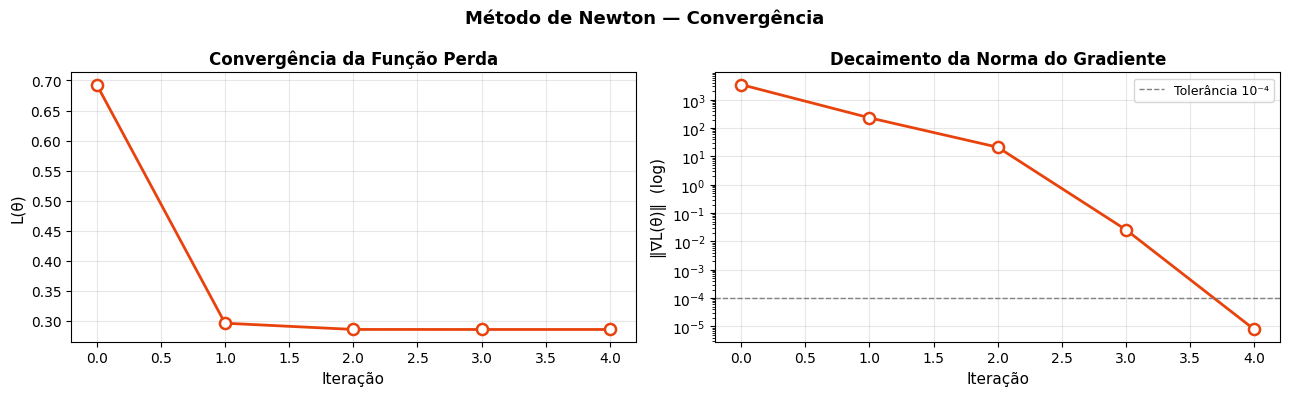

In [130]:
# Criar modelo com Método de Newton
modelo_newton = RegressaoLogistica(
    metodo_otimizacao='newton',
    metodo_busca='secao_aurea',
    tmax=100,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Método de Newton...")
t_inicio_nt = time.time()
modelo_newton.fit(X_train, y_train)
tempo_newton = time.time() - t_inicio_nt

print(f"Iterações para convergência: {modelo_newton.n_iteracoes_}")
print(f"Perda inicial → final:       {modelo_newton.historico_perda_[0]:.2f} → {modelo_newton.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:        {modelo_newton.historico_norma_grad_[0]:.2f} → {modelo_newton.historico_norma_grad_[-1]:.2e}")
print(f"Tempo de execução:           {tempo_newton:.2f}s")

# Gráfico de convergência
cor = '#E8430C'
mk = dict(marker='o', markersize=8, markerfacecolor='white', markeredgewidth=1.8)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(modelo_newton.historico_perda_, color=cor, linewidth=2.0, **mk)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(modelo_newton.historico_norma_grad_, color=cor, linewidth=2.0, **mk)
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Método de Newton — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7.1 Com balanceamento

Executando Método de Newton...
Iterações para convergência: 4
Perda inicial → final:       0.69 → 0.35
‖∇L‖ inicial → final:        458.42 → 3.43e-06
Tempo de execução:           0.31s


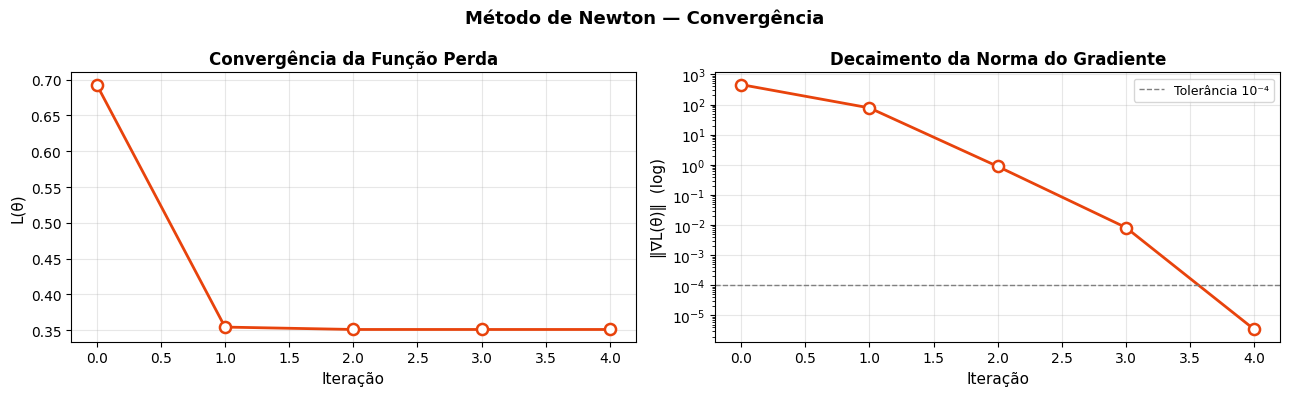

In [131]:
modelo_newton_balanced = RegressaoLogistica(
    metodo_otimizacao='newton',
    metodo_busca='secao_aurea',
    tmax=100,
    tolerancia=1e-4,
    lambda_=0.01
)

print("Executando Método de Newton...")
t_inicio_nt = time.time()
modelo_newton_balanced.fit(X_res, y_res)
tempo_newton_balanced = time.time() - t_inicio_nt

print(f"Iterações para convergência: {modelo_newton_balanced.n_iteracoes_}")
print(f"Perda inicial → final:       {modelo_newton_balanced.historico_perda_[0]:.2f} → {modelo_newton_balanced.historico_perda_[-1]:.2f}")
print(f"‖∇L‖ inicial → final:        {modelo_newton_balanced.historico_norma_grad_[0]:.2f} → {modelo_newton_balanced.historico_norma_grad_[-1]:.2e}")
print(f"Tempo de execução:           {tempo_newton_balanced:.2f}s")

# Gráfico de convergência
cor = '#E8430C'
mk = dict(marker='o', markersize=8, markerfacecolor='white', markeredgewidth=1.8)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(modelo_newton_balanced.historico_perda_, color=cor, linewidth=2.0, **mk)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(modelo_newton_balanced.historico_norma_grad_, color=cor, linewidth=2.0, **mk)
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('Método de Newton — Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação

**Evolução da Perda (esquerda):** $L(\theta)$ cai drasticamente nas primeiras iterações e estabiliza rapidamente — o Newton encontra a vizinhança do ótimo quase imediatamente.

**Norma do Gradiente (direita, escala log):** a queda abrupta de $\|\nabla L\|$ reflete a **convergência quadrática** — a cada iteração o erro é elevado ao quadrado, fazendo a norma despencar em pouquíssimas iterações (tipicamente 5–20).

> **Por que tão rápido?** A direção de Newton $d = -H^{-1}\nabla L$ usa a curvatura (Hessiana) para "prever" onde está o mínimo, enquanto o GD apenas segue o declive local. Perto do ótimo, o Newton se comporta quase como resolver $\nabla L(\theta^*) = 0$ diretamente.

---
## 8. Comparação dos Métodos de Otimização

Métrica                        GD (500 iters)       Newton
Iterações executadas                    500            4
Tempo de execução (s)                  16.2         0.28
Perda final L(θ)                     0.4248       0.2857
‖∇L(θ)‖ final                        6.5235     7.76e-06

Newton é ~125× mais eficiente em iterações
Newton é ~58× mais rápido em tempo de parede


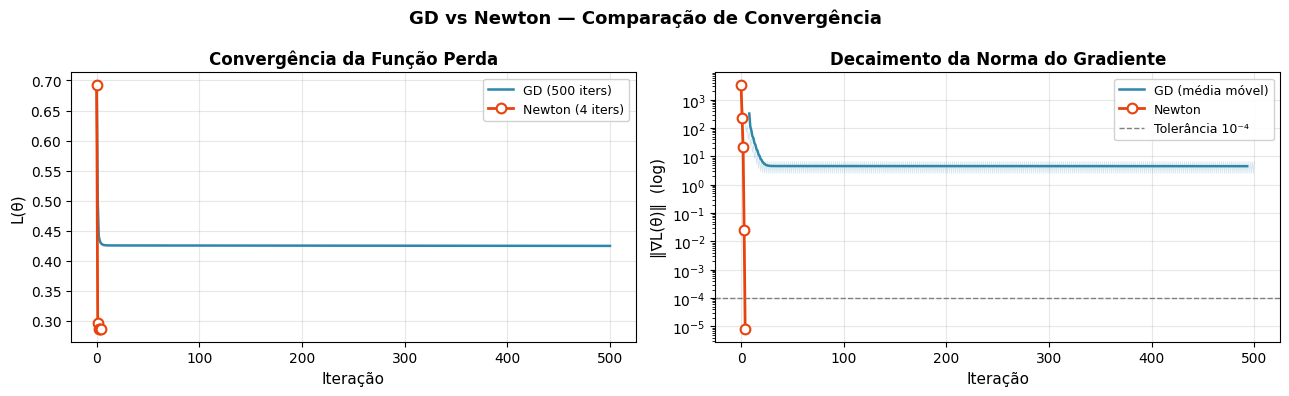

In [132]:
# --- Tabela comparativa ---
print("=" * 58)
print(f"{'Métrica':<30} {'GD (500 iters)':>12} {'Newton':>12}")
print("=" * 58)
print(f"{'Iterações executadas':<30} {modelo_gd.n_iteracoes_:>12d} {modelo_newton.n_iteracoes_:>12d}")
print(f"{'Tempo de execução (s)':<30} {tempo_gd:>12.1f} {tempo_newton:>12.2f}")
print(f"{'Perda final L(θ)':<30} {modelo_gd.historico_perda_[-1]:>12.4f} {modelo_newton.historico_perda_[-1]:>12.4f}")
print(f"{'‖∇L(θ)‖ final':<30} {modelo_gd.historico_norma_grad_[-1]:>12.4f} {modelo_newton.historico_norma_grad_[-1]:>12.2e}")
print("=" * 58)
print(f"\nNewton é ~{modelo_gd.n_iteracoes_/max(modelo_newton.n_iteracoes_,1):.0f}× mais eficiente em iterações")
print(f"Newton é ~{tempo_gd/max(tempo_newton,0.01):.0f}× mais rápido em tempo de parede")

# --- Curvas de convergência lado a lado ---
cor_gd = '#2E86AB'
cor_nt = '#E8430C'
mk_nt = dict(marker='o', markersize=7, markerfacecolor='white', markeredgewidth=1.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Perda
axes[0].plot(modelo_gd.historico_perda_, color=cor_gd, linewidth=1.8,
             label=f'GD ({modelo_gd.n_iteracoes_} iters)')
axes[0].plot(modelo_newton.historico_perda_, color=cor_nt, linewidth=2.0,
             label=f'Newton ({modelo_newton.n_iteracoes_} iters)', **mk_nt)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].grid(True, alpha=0.3)

# Norma do gradiente (log) com média móvel para GD
n_grad_gd = len(modelo_gd.historico_norma_grad_)
janela = max(5, n_grad_gd // 30)
mm_gd = np.convolve(modelo_gd.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
x_mm = range(janela//2, janela//2 + len(mm_gd))

axes[1].semilogy(range(n_grad_gd), modelo_gd.historico_norma_grad_, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[1].semilogy(x_mm, mm_gd, color=cor_gd, linewidth=1.8, label='GD (média móvel)')
axes[1].semilogy(modelo_newton.historico_norma_grad_, color=cor_nt, linewidth=2.0,
                 label='Newton', **mk_nt)
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('GD vs Newton — Comparação de Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.1 comparando os modelos treinados com os dados balanceados

Métrica                        GD (500 iters)       Newton
Iterações executadas                    500            4
Tempo de execução (s)                  27.2         0.31
Perda final L(θ)                     0.6731       0.3511
‖∇L(θ)‖ final                        4.7393     3.43e-06

Newton é ~125× mais eficiente em iterações
Newton é ~87× mais rápido em tempo de parede


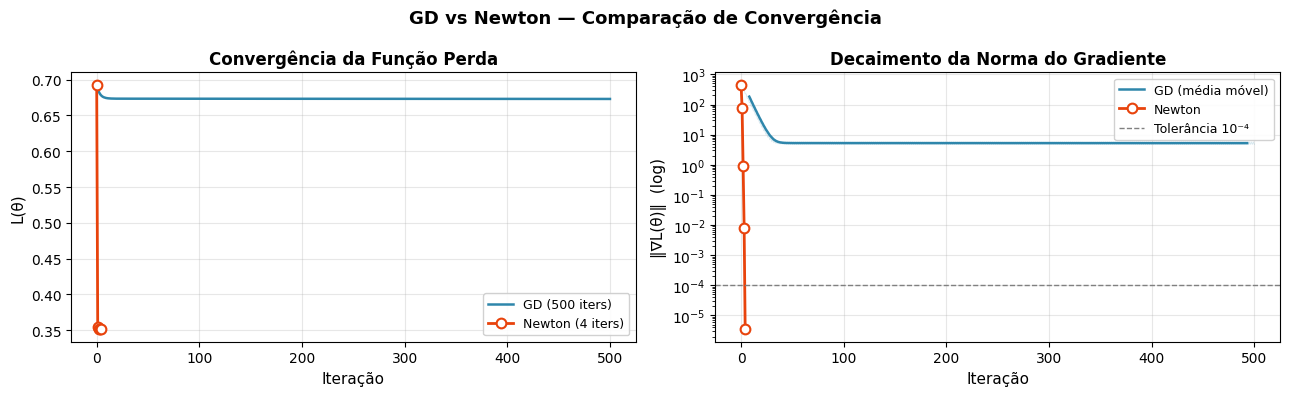

In [133]:
print("=" * 58)
print(f"{'Métrica':<30} {'GD (500 iters)':>12} {'Newton':>12}")
print("=" * 58)
print(f"{'Iterações executadas':<30} {modelo_gd_balanced.n_iteracoes_:>12d} {modelo_newton_balanced.n_iteracoes_:>12d}")
print(f"{'Tempo de execução (s)':<30} {tempo_gd_balanced:>12.1f} {tempo_newton_balanced:>12.2f}")
print(f"{'Perda final L(θ)':<30} {modelo_gd_balanced.historico_perda_[-1]:>12.4f} {modelo_newton_balanced.historico_perda_[-1]:>12.4f}")
print(f"{'‖∇L(θ)‖ final':<30} {modelo_gd_balanced.historico_norma_grad_[-1]:>12.4f} {modelo_newton_balanced.historico_norma_grad_[-1]:>12.2e}")
print("=" * 58)
print(f"\nNewton é ~{modelo_gd_balanced.n_iteracoes_/max(modelo_newton_balanced.n_iteracoes_,1):.0f}× mais eficiente em iterações")
print(f"Newton é ~{tempo_gd_balanced/max(tempo_newton_balanced,0.01):.0f}× mais rápido em tempo de parede")

# --- Curvas de convergência lado a lado ---
cor_gd = '#2E86AB'
cor_nt = '#E8430C'
mk_nt = dict(marker='o', markersize=7, markerfacecolor='white', markeredgewidth=1.5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Perda
axes[0].plot(modelo_gd_balanced.historico_perda_, color=cor_gd, linewidth=1.8,
             label=f'GD ({modelo_gd_balanced.n_iteracoes_} iters)')
axes[0].plot(modelo_newton_balanced.historico_perda_, color=cor_nt, linewidth=2.0,
             label=f'Newton ({modelo_newton_balanced.n_iteracoes_} iters)', **mk_nt)
axes[0].set_xlabel('Iteração', fontsize=11)
axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Convergência da Função Perda', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].grid(True, alpha=0.3)

# Norma do gradiente (log) com média móvel para GD
n_grad_gd = len(modelo_gd_balanced.historico_norma_grad_)
janela = max(5, n_grad_gd // 30)
mm_gd = np.convolve(modelo_gd_balanced.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
x_mm = range(janela//2, janela//2 + len(mm_gd))

axes[1].semilogy(range(n_grad_gd), modelo_gd_balanced.historico_norma_grad_, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[1].semilogy(x_mm, mm_gd, color=cor_gd, linewidth=1.8, label='GD (média móvel)')
axes[1].semilogy(modelo_newton_balanced.historico_norma_grad_, color=cor_nt, linewidth=2.0,
                 label='Newton', **mk_nt)
axes[1].axhline(1e-4, linestyle='--', color='gray', linewidth=1.0, label='Tolerância 10⁻⁴')
axes[1].set_xlabel('Iteração', fontsize=11)
axes[1].set_ylabel('‖∇L(θ)‖  (log)', fontsize=11)
axes[1].set_title('Decaimento da Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('GD vs Newton — Comparação de Convergência', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação

**Perda (esquerda):** as curvas de GD e Newton partem do mesmo ponto, mas o Newton (laranja) converge em poucas iterações enquanto o GD (azul) ainda está descendo lentamente após 500 iterações. Ambos alcançam perdas finais similares, confirmando que convergem para o mesmo mínimo global (garantido pela convexidade de $L$).

**Norma do Gradiente (direita):** a escala logarítmica evidencia a diferença de velocidade — o Newton reduz $\|\nabla L\|$ por ordens de grandeza a cada iteração, enquanto o GD faz reduções incrementais constantes.

> **Conclusão prática:** o Newton é ordens de grandeza mais eficiente em iterações, mas cada iteração custa mais (resolver sistema linear $H \cdot d = -\nabla L$ em $O(p^3)$). Para problemas com poucas features (como este), o Newton é amplamente superior.

### Convergência em Função do Tempo de Execução

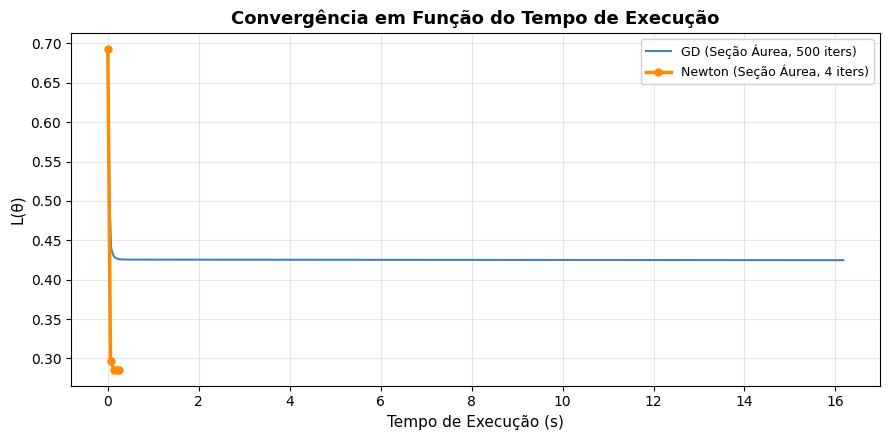

In [134]:
# === Gráfico 12: Convergência em Função do Tempo de Execução ===
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(modelo_gd.historico_tempo_, modelo_gd.historico_perda_,
        color='steelblue', linewidth=1.5, label=f'GD (Seção Áurea, {modelo_gd.n_iteracoes_} iters)')
ax.plot(modelo_newton.historico_tempo_, modelo_newton.historico_perda_,
        color='darkorange', linewidth=2.5, marker='o', markersize=5,
        label=f'Newton (Seção Áurea, {modelo_newton.n_iteracoes_} iters)')

ax.set_xlabel('Tempo de Execução (s)', fontsize=11)
ax.set_ylabel('L(θ)', fontsize=11)
ax.set_title('Convergência em Função do Tempo de Execução', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8.2 Comparação dos Métodos de Busca em Linha

Treinamos o Gradiente Descendente com cada um dos 3 métodos de busca disponíveis para comparar eficiência.

Seção Áurea            — 200 iters, perda final: 0.4252, tempo: 7.79s
Partição Igual         — 200 iters, perda final: 0.5698, tempo: 7.58s
Ajuste Quadrático      — 200 iters, perda final: 5.5649, tempo: 6.76s


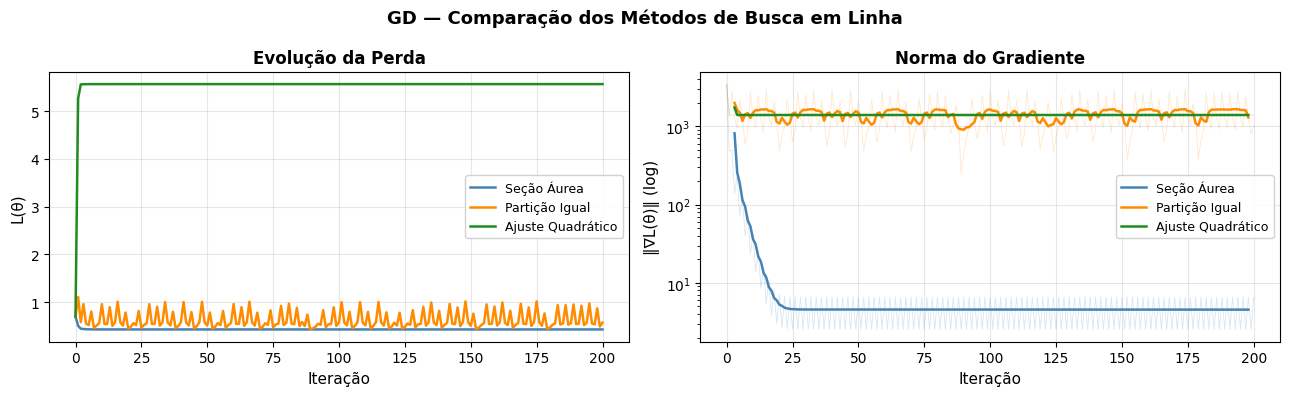

In [135]:
metodos_busca = ['secao_aurea', 'particao_igual', 'ajuste_quadratico']
nomes_busca   = ['Seção Áurea', 'Partição Igual', 'Ajuste Quadrático']
nomes_busca_list = nomes_busca  # alias para células posteriores
cores_busca   = ['steelblue', 'darkorange', 'forestgreen']
modelos_gd_busca = {}

for metodo, nome in zip(metodos_busca, nomes_busca):
    modelo = RegressaoLogistica(
        metodo_otimizacao='gradiente_descendente',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t1 = time.time()
    modelos_gd_busca[nome] = modelo
    print(f"{nome:<22} — {modelo.n_iteracoes_} iters, "
          f"perda final: {modelo.historico_perda_[-1]:.4f}, tempo: {t1-t0:.2f}s")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for nome, cor in zip(nomes_busca, cores_busca):
    m = modelos_gd_busca[nome]

    # Painel esquerdo: Perda (curva única — geralmente suave)
    axes[0].plot(m.historico_perda_, color=cor, linewidth=1.8, label=nome)

    # Painel direito: Norma do gradiente com média móvel
    n = len(m.historico_norma_grad_)
    janela = max(5, n // 30)
    mm = np.convolve(m.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
    x_mm = range(janela//2, janela//2 + len(mm))
    axes[1].semilogy(range(n), m.historico_norma_grad_, color=cor, linewidth=0.6, alpha=0.2)
    axes[1].semilogy(x_mm, mm, color=cor, linewidth=1.8, label=nome)

axes[0].set_xlabel('Iteração', fontsize=11); axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Evolução da Perda', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteração', fontsize=11); axes[1].set_ylabel('‖∇L(θ)‖ (log)', fontsize=11)
axes[1].set_title('Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9); axes[1].grid(True, alpha=0.3)

fig.suptitle('GD — Comparação dos Métodos de Busca em Linha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.2.1 Com os dados balanceados

Seção Áurea            — 200 iters, perda final: 0.6733, tempo: 10.35s
Partição Igual         — 200 iters, perda final: 0.9083, tempo: 12.19s
Ajuste Quadrático      — 200 iters, perda final: 0.6730, tempo: 4.54s


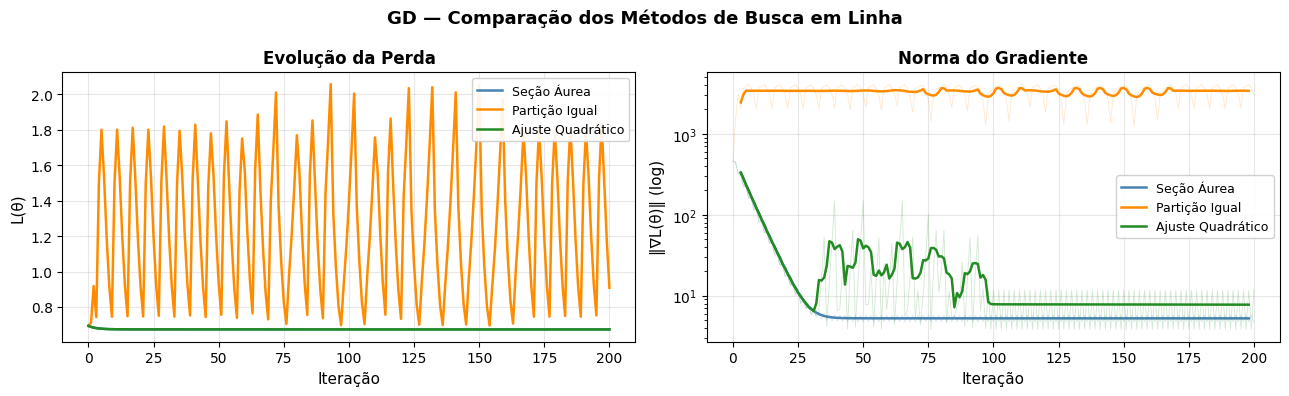

In [136]:
metodos_busca = ['secao_aurea', 'particao_igual', 'ajuste_quadratico']
nomes_busca   = ['Seção Áurea', 'Partição Igual', 'Ajuste Quadrático']
cores_busca   = ['steelblue', 'darkorange', 'forestgreen']
modelos_gd_busca_balanced = {}

for metodo, nome in zip(metodos_busca, nomes_busca):
    modelo_balanced = RegressaoLogistica(
        metodo_otimizacao='gradiente_descendente',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    t0 = time.time()
    modelo_balanced.fit(X_res, y_res)
    t1 = time.time()
    modelos_gd_busca_balanced[nome] = modelo_balanced
    print(f"{nome:<22} — {modelo_balanced.n_iteracoes_} iters, "
          f"perda final: {modelo_balanced.historico_perda_[-1]:.4f}, tempo: {t1-t0:.2f}s")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for nome, cor in zip(nomes_busca, cores_busca):
    m = modelos_gd_busca_balanced[nome]

    axes[0].plot(m.historico_perda_, color=cor, linewidth=1.8, label=nome)

    n = len(m.historico_norma_grad_)
    janela = max(5, n // 30)
    mm = np.convolve(m.historico_norma_grad_, np.ones(janela)/janela, mode='valid')
    x_mm = range(janela//2, janela//2 + len(mm))
    axes[1].semilogy(range(n), m.historico_norma_grad_, color=cor, linewidth=0.6, alpha=0.2)
    axes[1].semilogy(x_mm, mm, color=cor, linewidth=1.8, label=nome)

axes[0].set_xlabel('Iteração', fontsize=11); axes[0].set_ylabel('L(θ)', fontsize=11)
axes[0].set_title('Evolução da Perda', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Iteração', fontsize=11); axes[1].set_ylabel('‖∇L(θ)‖ (log)', fontsize=11)
axes[1].set_title('Norma do Gradiente', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9); axes[1].grid(True, alpha=0.3)

fig.suptitle('GD — Comparação dos Métodos de Busca em Linha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação

**Perda (esquerda):** os três métodos de busca em linha produzem trajetórias de convergência muito similares — todos encontram passos $\alpha^*$ próximos do ótimo a cada iteração.

**Norma do Gradiente (direita):** as curvas praticamente se sobrepõem, indicando que a escolha do método de busca tem **impacto marginal** na qualidade da solução. A diferença principal está na eficiência computacional:

- **Seção Áurea:** 1 avaliação de $g(\alpha)$ por iteração interna (reaproveitamento de ponto), reduz intervalo por $\varphi \approx 0.618$ por passo — melhor relação custo/benefício.
- **Partição Igual (trisseção):** 2 avaliações por iteração, reduz por $2/3 \approx 0.667$ — ligeiramente menos eficiente.
- **Ajuste Quadrático:** convergência potencialmente mais rápida quando $g$ é suave, mas sensível a ruído numérico.

> **Conclusão:** para este problema, qualquer método de busca funciona bem. A seção áurea é a escolha padrão por ser robusta e eficiente.

## 8.2.2 Eficiência Computacional das Combinações

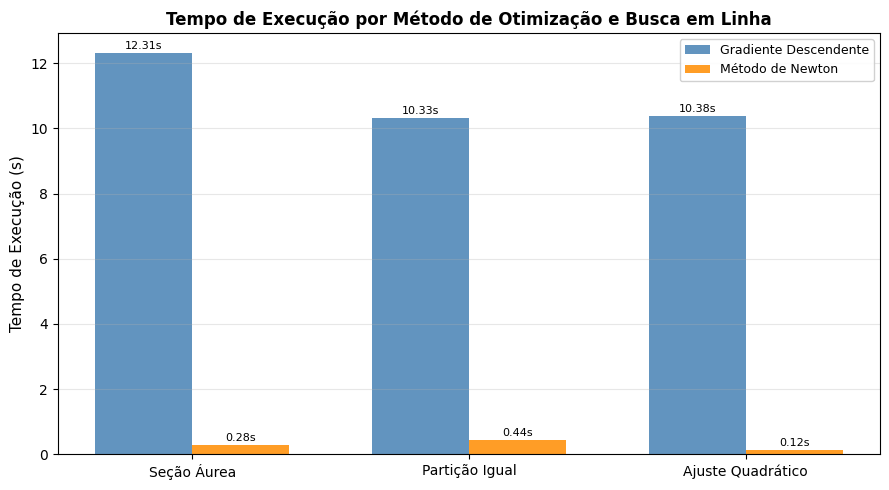

In [137]:
import time as _time

# === Gráfico 3: Tempo de Execução — Barras Agrupadas (GD vs Newton × 3 buscas) ===
metodos_busca_list = ['secao_aurea', 'particao_igual', 'ajuste_quadratico']
nomes_busca_list   = ['Seção Áurea', 'Partição Igual', 'Ajuste Quadrático']

tempos_gd     = []
tempos_newton = []

for metodo in metodos_busca_list:
    m_gd = RegressaoLogistica(
        metodo_otimizacao='gradiente_descendente',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    t0 = _time.perf_counter()
    m_gd.fit(X_train, y_train)
    tempos_gd.append(_time.perf_counter() - t0)

    m_nt = RegressaoLogistica(
        metodo_otimizacao='newton',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    t0 = _time.perf_counter()
    m_nt.fit(X_train, y_train)
    tempos_newton.append(_time.perf_counter() - t0)

x = np.arange(len(nomes_busca_list))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_gd = ax.bar(x - largura/2, tempos_gd, largura,
                   label='Gradiente Descendente', color='steelblue', alpha=0.85)
barras_nt = ax.bar(x + largura/2, tempos_newton, largura,
                   label='Método de Newton', color='darkorange', alpha=0.85)

for barra in barras_gd:
    ax.annotate(f'{barra.get_height():.2f}s',
                xy=(barra.get_x() + barra.get_width()/2, barra.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for barra in barras_nt:
    ax.annotate(f'{barra.get_height():.2f}s',
                xy=(barra.get_x() + barra.get_width()/2, barra.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(nomes_busca_list)
ax.set_ylabel('Tempo de Execução (s)', fontsize=11)
ax.set_title('Tempo de Execução por Método de Otimização e Busca em Linha', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


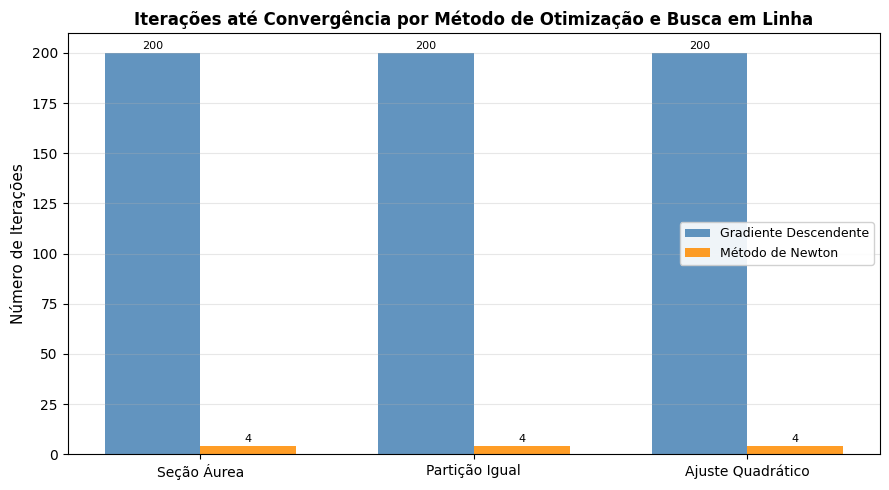

In [138]:
# === Gráfico 4: Número de Iterações — Barras Agrupadas ===
iters_gd     = []
iters_newton = []

modelos_gd_busca     = {}
modelos_newton_busca = {}

for metodo, nome in zip(metodos_busca_list, nomes_busca_list):
    m_gd = RegressaoLogistica(
        metodo_otimizacao='gradiente_descendente',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    m_gd.fit(X_train, y_train)
    iters_gd.append(m_gd.n_iteracoes_)
    modelos_gd_busca[nome] = m_gd

    m_nt = RegressaoLogistica(
        metodo_otimizacao='newton',
        metodo_busca=metodo, tmax=200, tolerancia=1e-4, lambda_=0.01
    )
    m_nt.fit(X_train, y_train)
    iters_newton.append(m_nt.n_iteracoes_)
    modelos_newton_busca[nome] = m_nt

fig, ax = plt.subplots(figsize=(9, 5))
barras_gd = ax.bar(x - largura/2, iters_gd, largura,
                   label='Gradiente Descendente', color='steelblue', alpha=0.85)
barras_nt = ax.bar(x + largura/2, iters_newton, largura,
                   label='Método de Newton', color='darkorange', alpha=0.85)

for barra in barras_gd:
    ax.annotate(f'{int(barra.get_height())}',
                xy=(barra.get_x() + barra.get_width()/2, barra.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for barra in barras_nt:
    ax.annotate(f'{int(barra.get_height())}',
                xy=(barra.get_x() + barra.get_width()/2, barra.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(nomes_busca_list)
ax.set_ylabel('Número de Iterações', fontsize=11)
ax.set_title('Iterações até Convergência por Método de Otimização e Busca em Linha', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


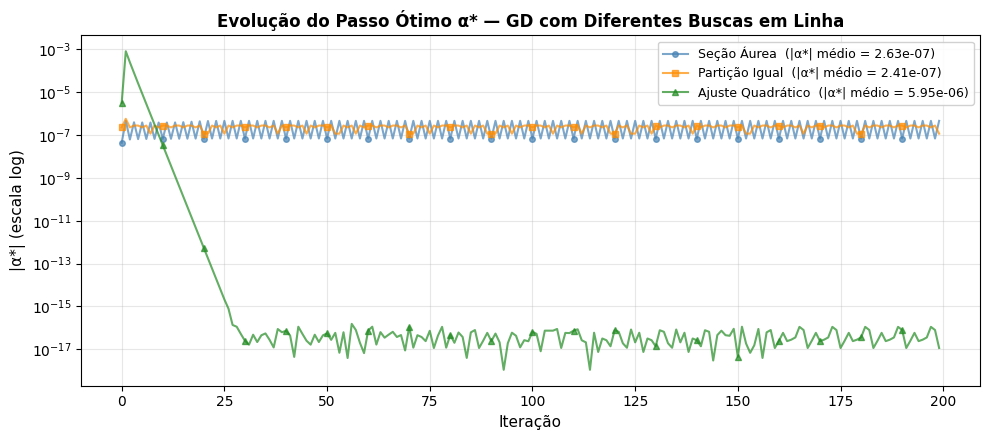

In [139]:
# === Gráfico 5: Evolução do Passo α* para GD com cada método de busca ===
cores_busca_5 = ['steelblue', 'darkorange', 'forestgreen']
markers_busca = ['o', 's', '^']

fig, ax = plt.subplots(figsize=(10, 4.5))

for nome, cor, mk in zip(nomes_busca_list, cores_busca_5, markers_busca):
    m = modelos_gd_busca[nome]
    alphas = np.abs(m.historico_alpha_)   # ajuste quadrático pode retornar α negativo → valor absoluto
    n = len(alphas)
    media_alpha = np.mean(alphas)
    label_texto = f"{nome}  (|α*| médio = {media_alpha:.2e})"
    ax.plot(range(n), alphas,
            color=cor, linewidth=1.5, alpha=0.7,
            marker=mk, markevery=max(1, n // 20), markersize=4,
            label=label_texto)

ax.set_yscale('log')
ax.set_xlabel('Iteração', fontsize=11)
ax.set_ylabel('|α*| (escala log)', fontsize=11)
ax.set_title('Evolução do Passo Ótimo α* — GD com Diferentes Buscas em Linha',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Interpretação

**Gráfico 3 — Tempo de Execução:** o Método de Newton tende a ser mais rápido em tempo de parede por requerer menos iterações, apesar de cada iteração ser mais custosa (resolução de sistema linear $O(p^3)$). Entre os métodos de busca, a Seção Áurea geralmente apresenta menor tempo total por reutilizar avaliações de $g(\alpha)$.

**Gráfico 4 — Número de Iterações:** o Newton converge em muito menos iterações que o GD para qualquer método de busca, evidenciando a superioridade da convergência quadrática. O método de busca tem impacto marginal no número de iterações totais.

**Gráfico 5 — Evolução do Passo α*:** os três métodos de busca produzem trajetórias de $\alpha^*$ similares ao longo das iterações do GD. O passo ótimo tende a diminuir conforme o modelo se aproxima do mínimo, refletindo a curvatura local da função de perda.

> **Conclusão:** a escolha do método de busca em linha tem impacto principalmente na eficiência computacional por iteração, não na qualidade da solução final.

---
## 8.3 Número de Condição e Taxa de Convergência

O número de condição $\kappa(H) = \lambda_{\max}/\lambda_{\min}$ governa a velocidade do GD. Acompanhamos $\kappa$ ao longo das iterações do Newton para mostrar como a curvatura muda conforme o modelo converge.

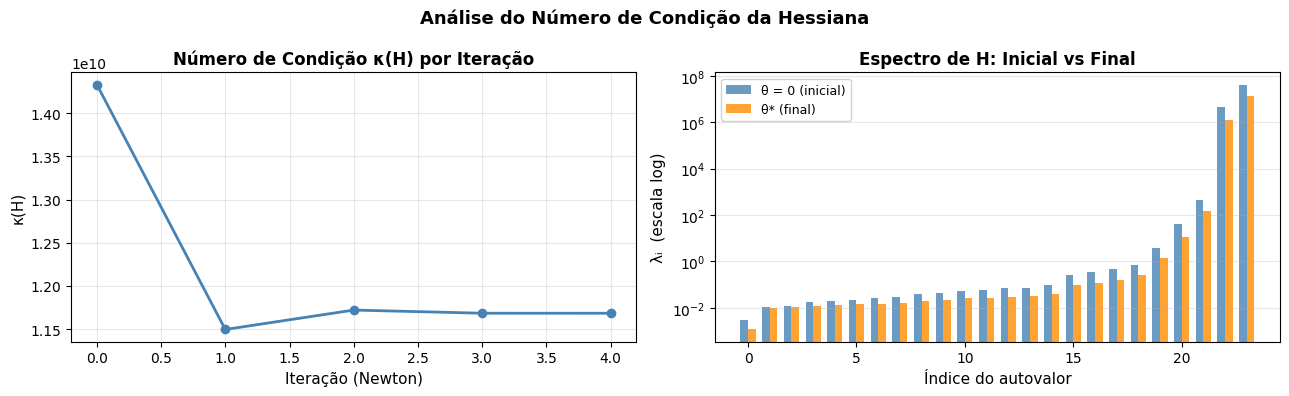

κ inicial: 14331987083.8
κ final:   11683133253.0


In [140]:
# Recalcular Hessiana em alguns pontos ao longo do treinamento do Newton
# para ver como κ(H) evolui
X_b_full = np.c_[np.ones(np.array(X_train).shape[0]), np.array(X_train, dtype=float)]
w_teste = np.zeros(X_b_full.shape[1])
y_np_full = np.array(y_train, dtype=float)

# Simular Newton manualmente para coletar κ a cada iteração
kappas = []
w = w_teste.copy()
for _ in range(modelo_newton.n_iteracoes_ + 1):
    H = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
    avs = np.linalg.eigvalsh(H)
    kappas.append(avs.max() / max(avs.min(), 1e-12))
    grad = RegressaoLogistica._gradiente(w, X_b_full, y_np_full, 0.01)
    if np.linalg.norm(grad) < 1e-6:
        break
    H_reg = H + 1e-8 * np.eye(H.shape[0])
    d = np.linalg.solve(H_reg, -grad)
    g = lambda a: RegressaoLogistica._funcao_perda(w + a * d, X_b_full, y_np_full, 0.01)
    a0_, b0_ = RegressaoLogistica._intervalo_inicial(g)
    alpha = RegressaoLogistica._busca_secao_aurea(g, a0_, b0_)
    w = w + alpha * d

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# κ ao longo das iterações
axes[0].plot(range(len(kappas)), kappas, color='steelblue', linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Iteração (Newton)', fontsize=11)
axes[0].set_ylabel('κ(H)', fontsize=11)
axes[0].set_title('Número de Condição κ(H) por Iteração', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Espectro de autovalores: escala log para mostrar amplitude completa
H_final = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
avs_final = np.linalg.eigvalsh(H_final)
avs_inicial = np.linalg.eigvalsh(RegressaoLogistica._hessiana(w_teste, X_b_full, 0.01))

x_pos = np.arange(len(avs_final))
largura = 0.35
axes[1].bar(x_pos - largura/2, avs_inicial, largura, color='steelblue', label='θ = 0 (inicial)', alpha=0.8)
axes[1].bar(x_pos + largura/2, avs_final,   largura, color='darkorange', label='θ* (final)', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Índice do autovalor', fontsize=11)
axes[1].set_ylabel('λᵢ  (escala log)', fontsize=11)
axes[1].set_title('Espectro de H: Inicial vs Final', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Análise do Número de Condição da Hessiana', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"κ inicial: {kappas[0]:.1f}")
print(f"κ final:   {kappas[-1]:.1f}")

## 8.3.1 Com balanceamento

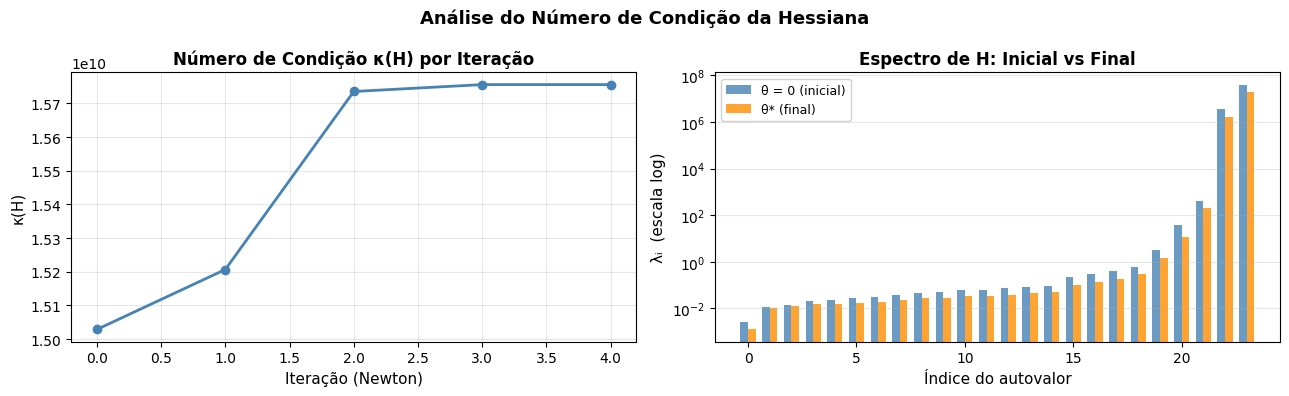

κ inicial: 15028685620.3
κ final:   15755996070.2


In [141]:
X_b_full = np.c_[np.ones(np.array(X_res).shape[0]), np.array(X_res, dtype=float)]
w_teste = np.zeros(X_b_full.shape[1])
y_np_full = np.array(y_res, dtype=float)

# Simular Newton manualmente para coletar κ a cada iteração
kappas = []
w = w_teste.copy()
for _ in range(modelo_newton_balanced.n_iteracoes_ + 1):
    H = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
    avs = np.linalg.eigvalsh(H)
    kappas.append(avs.max() / max(avs.min(), 1e-12))
    grad = RegressaoLogistica._gradiente(w, X_b_full, y_np_full, 0.01)
    if np.linalg.norm(grad) < 1e-6:
        break
    H_reg = H + 1e-8 * np.eye(H.shape[0])
    d = np.linalg.solve(H_reg, -grad)
    g = lambda a: RegressaoLogistica._funcao_perda(w + a * d, X_b_full, y_np_full, 0.01)
    a0_, b0_ = RegressaoLogistica._intervalo_inicial(g)
    alpha = RegressaoLogistica._busca_secao_aurea(g, a0_, b0_)
    w = w + alpha * d

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# κ ao longo das iterações
axes[0].plot(range(len(kappas)), kappas, color='steelblue', linewidth=2, marker='o', markersize=6)
axes[0].set_xlabel('Iteração (Newton)', fontsize=11)
axes[0].set_ylabel('κ(H)', fontsize=11)
axes[0].set_title('Número de Condição κ(H) por Iteração', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Espectro de autovalores: escala log para mostrar amplitude completa
H_final = RegressaoLogistica._hessiana(w, X_b_full, 0.01)
avs_final = np.linalg.eigvalsh(H_final)
avs_inicial = np.linalg.eigvalsh(RegressaoLogistica._hessiana(w_teste, X_b_full, 0.01))

x_pos = np.arange(len(avs_final))
largura = 0.35
axes[1].bar(x_pos - largura/2, avs_inicial, largura, color='steelblue', label='θ = 0 (inicial)', alpha=0.8)
axes[1].bar(x_pos + largura/2, avs_final,   largura, color='darkorange', label='θ* (final)', alpha=0.8)
axes[1].set_yscale('log')
axes[1].set_xlabel('Índice do autovalor', fontsize=11)
axes[1].set_ylabel('λᵢ  (escala log)', fontsize=11)
axes[1].set_title('Espectro de H: Inicial vs Final', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Análise do Número de Condição da Hessiana', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"κ inicial: {kappas[0]:.1f}")
print(f"κ final:   {kappas[-1]:.1f}")

### Interpretação

**Número de Condição $\kappa(H)$ (esquerda):** mede a "dificuldade" do problema para o otimizador. Valores altos de $\kappa$ significam que a Hessiana tem autovalores muito dispersos, tornando o sistema $H \cdot d = -\nabla L$ mais sensível a erros numéricos. Ao longo das iterações do Newton, $\kappa$ tende a estabilizar conforme $\theta$ se aproxima do ótimo.

**Espectro de $H$: Inicial vs Final (direita):** compara os autovalores da Hessiana no ponto inicial ($\theta = 0$) e no ótimo ($\theta^*$). A mudança no espectro reflete como a curvatura da superfície de perda varia conforme o modelo aprende — a regularização L2 ($\lambda I$) impede que autovalores fiquem muito próximos de zero, melhorando o condicionamento.

> **Conexão com a teoria (Aula 02):** a taxa de convergência do GD depende diretamente de $\kappa(H)$: quanto maior $\kappa$, mais lento. O Newton é menos afetado por $\kappa$ pois a multiplicação por $H^{-1}$ "normaliza" as curvaturas em todas as direções.

---
## 8.4 Taxa de Convergência: Linear vs Quadrática

A **taxa de convergência** mede quão rápido $\|\nabla L\|$ diminui entre iterações consecutivas.

- **Convergência linear** (GD): $\|\nabla L_{k+1}\| \approx c \cdot \|\nabla L_k\|$, com $c \in (0,1)$ constante — a razão $r_k = \|\nabla L_{k+1}\| / \|\nabla L_k\|$ estabiliza num patamar.
- **Convergência quadrática** (Newton): $\|\nabla L_{k+1}\| \approx c \cdot \|\nabla L_k\|^2$ — a razão $r_k \to 0$, indicando que o erro se reduz cada vez mais rápido.

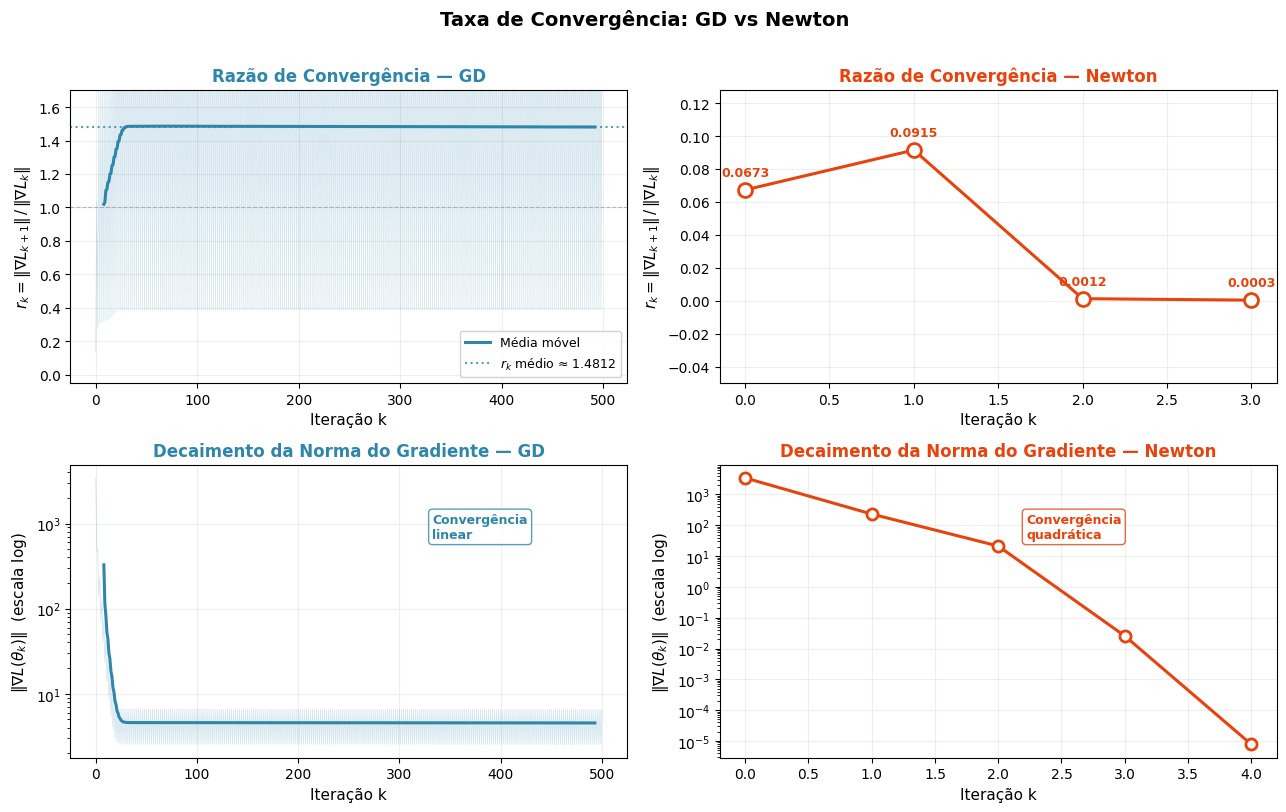

Razão média (GD, últimas iterações):     1.4812  ← constante ≈ convergência linear
Razão final (Newton):                    0.000302  ← tendendo a 0 ≈ convergência quadrática


In [142]:
# === Taxa de convergência: razão entre normas consecutivas ===
grad_gd = modelo_gd.historico_norma_grad_
grad_nt = modelo_newton.historico_norma_grad_

# Razão r_k = ||∇L_{k+1}|| / ||∇L_k||  (convergência linear → constante)
razao_gd = [grad_gd[k+1] / grad_gd[k] for k in range(len(grad_gd)-1) if grad_gd[k] > 1e-15]
razao_nt = [grad_nt[k+1] / grad_nt[k] for k in range(len(grad_nt)-1) if grad_nt[k] > 1e-15]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

cor_gd = '#2E86AB'
cor_nt = '#E8430C'

# --- Linha 1, Esquerda: Razão de convergência — GD ---
janela = max(10, len(razao_gd) // 30)
media_movel_r = np.convolve(razao_gd, np.ones(janela)/janela, mode='valid')
x_media_r = range(janela//2, janela//2 + len(media_movel_r))

axes[0, 0].plot(razao_gd, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[0, 0].plot(x_media_r, media_movel_r, color=cor_gd, linewidth=2.2, label='Média móvel')
axes[0, 0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
if len(razao_gd) > 0:
    media_r_gd = np.mean(razao_gd[-min(50, len(razao_gd)):])
    y_max = max(1.15, media_r_gd * 1.15)
    axes[0, 0].axhline(media_r_gd, color=cor_gd, linestyle=':', linewidth=1.5, alpha=0.8,
                       label=f'$r_k$ médio ≈ {media_r_gd:.4f}')
    axes[0, 0].set_ylim(-0.05, y_max)
axes[0, 0].legend(fontsize=9, framealpha=0.9)
axes[0, 0].set_xlabel('Iteração k', fontsize=11)
axes[0, 0].set_ylabel(r'$r_k = \|\nabla L_{k+1}\| \,/\, \|\nabla L_k\|$', fontsize=11)
axes[0, 0].set_title('Razão de Convergência — GD', fontsize=12, fontweight='bold', color=cor_gd)
axes[0, 0].grid(True, alpha=0.2)

# --- Linha 1, Direita: Razão de convergência — Newton ---
axes[0, 1].plot(range(len(razao_nt)), razao_nt, color=cor_nt, linewidth=2.2,
                marker='o', markersize=10, markerfacecolor='white', markeredgewidth=2)
for i, v in enumerate(razao_nt):
    axes[0, 1].annotate(f'{v:.4f}', xy=(i, v),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, color=cor_nt, fontweight='bold')
axes[0, 1].set_xlabel('Iteração k', fontsize=11)
axes[0, 1].set_ylabel(r'$r_k = \|\nabla L_{k+1}\| \,/\, \|\nabla L_k\|$', fontsize=11)
axes[0, 1].set_title('Razão de Convergência — Newton', fontsize=12, fontweight='bold', color=cor_nt)
axes[0, 1].set_ylim(-0.05, max(razao_nt) * 1.4 if razao_nt else 1.15)
axes[0, 1].grid(True, alpha=0.2)

# --- Linha 2, Esquerda: Norma gradiente (log) — GD ---
janela_g = max(10, len(grad_gd) // 30)
media_movel_g = np.convolve(grad_gd, np.ones(janela_g)/janela_g, mode='valid')
x_media_g = range(janela_g//2, janela_g//2 + len(media_movel_g))

axes[1, 0].semilogy(range(len(grad_gd)), grad_gd, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[1, 0].semilogy(x_media_g, media_movel_g, color=cor_gd, linewidth=2.2, label='Média móvel')
axes[1, 0].text(0.65, 0.75, 'Convergência\nlinear',
                transform=axes[1, 0].transAxes,
                fontsize=9, color=cor_gd, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=cor_gd, alpha=0.8))
axes[1, 0].set_xlabel('Iteração k', fontsize=11)
axes[1, 0].set_ylabel(r'$\|\nabla L(\theta_k)\|$  (escala log)', fontsize=11)
axes[1, 0].set_title('Decaimento da Norma do Gradiente — GD', fontsize=12, fontweight='bold', color=cor_gd)
axes[1, 0].grid(True, alpha=0.2)

# --- Linha 2, Direita: Norma gradiente (log) — Newton ---
axes[1, 1].semilogy(range(len(grad_nt)), grad_nt, color=cor_nt, linewidth=2.2,
                    marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1, 1].text(0.55, 0.75, 'Convergência\nquadrática',
                transform=axes[1, 1].transAxes,
                fontsize=9, color=cor_nt, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=cor_nt, alpha=0.8))
axes[1, 1].set_xlabel('Iteração k', fontsize=11)
axes[1, 1].set_ylabel(r'$\|\nabla L(\theta_k)\|$  (escala log)', fontsize=11)
axes[1, 1].set_title('Decaimento da Norma do Gradiente — Newton', fontsize=12, fontweight='bold', color=cor_nt)
axes[1, 1].grid(True, alpha=0.2)

fig.suptitle('Taxa de Convergência: GD vs Newton', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Estatísticas
if len(razao_gd) > 10:
    media_razao_gd = np.mean(razao_gd[-min(50, len(razao_gd)):])
    print(f"Razão média (GD, últimas iterações):     {media_razao_gd:.4f}  ← constante ≈ convergência linear")
if len(razao_nt) > 1:
    print(f"Razão final (Newton):                    {razao_nt[-1]:.6f}  ← tendendo a 0 ≈ convergência quadrática")

## 8.4.1 Com balanceamento

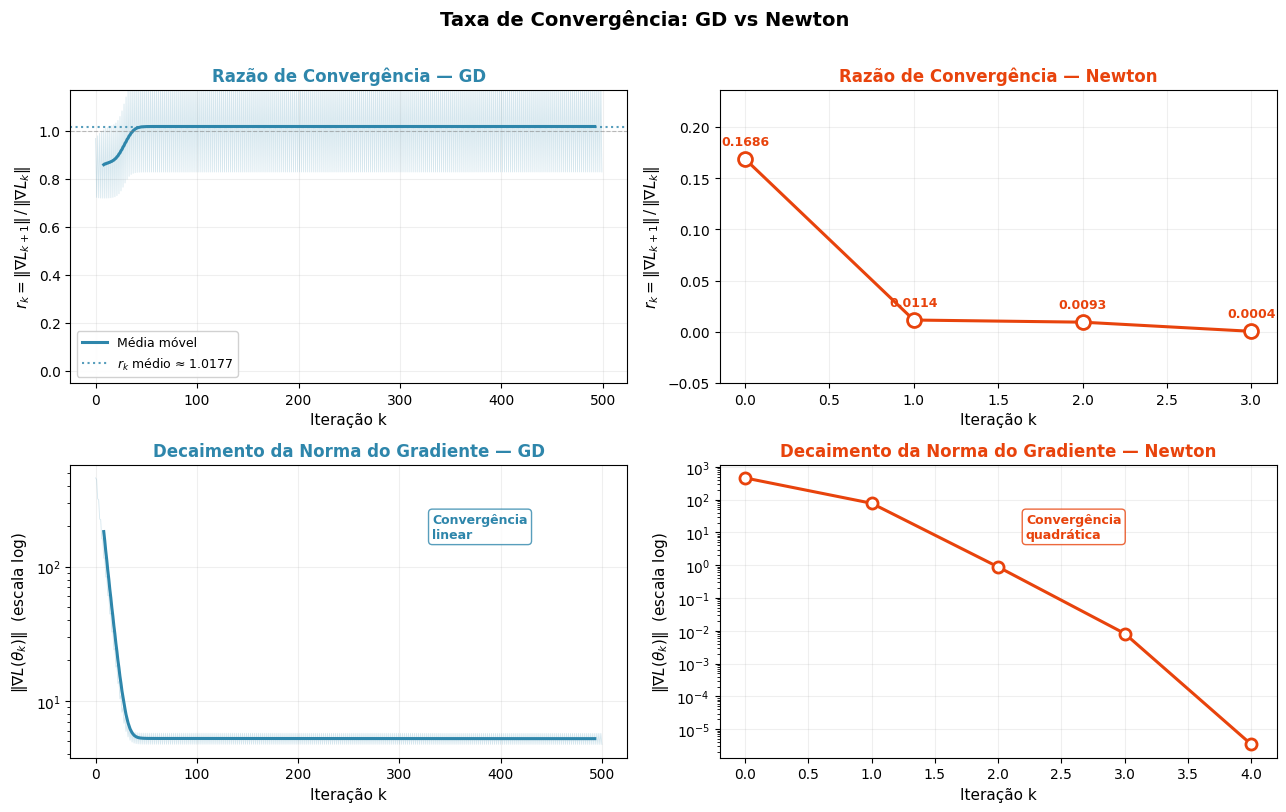

Razão média (GD, últimas iterações):     1.0177  ← constante ≈ convergência linear
Razão final (Newton):                    0.000416  ← tendendo a 0 ≈ convergência quadrática


In [143]:
grad_gd_balanced = modelo_gd_balanced.historico_norma_grad_
grad_nt_balanced = modelo_newton_balanced.historico_norma_grad_

# Razão r_k = ||∇L_{k+1}|| / ||∇L_k||  (convergência linear → constante)
razao_gd_balanced = [grad_gd_balanced[k+1] / grad_gd_balanced[k] for k in range(len(grad_gd_balanced)-1) if grad_gd_balanced[k] > 1e-15]
razao_nt_balanced = [grad_nt_balanced[k+1] / grad_nt_balanced[k] for k in range(len(grad_nt_balanced)-1) if grad_nt_balanced[k] > 1e-15]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

cor_gd = '#2E86AB'
cor_nt = '#E8430C'

# --- Linha 1, Esquerda: Razão de convergência — GD ---
janela = max(10, len(razao_gd_balanced) // 30)
media_movel_r = np.convolve(razao_gd_balanced, np.ones(janela)/janela, mode='valid')
x_media_r = range(janela//2, janela//2 + len(media_movel_r))

axes[0, 0].plot(razao_gd_balanced, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[0, 0].plot(x_media_r, media_movel_r, color=cor_gd, linewidth=2.2, label='Média móvel')
axes[0, 0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
if len(razao_gd_balanced) > 0:
    media_r_gd = np.mean(razao_gd_balanced[-min(50, len(razao_gd_balanced)):])
    y_max = max(1.15, media_r_gd * 1.15)
    axes[0, 0].axhline(media_r_gd, color=cor_gd, linestyle=':', linewidth=1.5, alpha=0.8,
                       label=f'$r_k$ médio ≈ {media_r_gd:.4f}')
    axes[0, 0].set_ylim(-0.05, y_max)
axes[0, 0].legend(fontsize=9, framealpha=0.9)
axes[0, 0].set_xlabel('Iteração k', fontsize=11)
axes[0, 0].set_ylabel(r'$r_k = \|\nabla L_{k+1}\| \,/\, \|\nabla L_k\|$', fontsize=11)
axes[0, 0].set_title('Razão de Convergência — GD', fontsize=12, fontweight='bold', color=cor_gd)
axes[0, 0].grid(True, alpha=0.2)

# --- Linha 1, Direita: Razão de convergência — Newton ---
axes[0, 1].plot(range(len(razao_nt_balanced)), razao_nt_balanced, color=cor_nt, linewidth=2.2,
                marker='o', markersize=10, markerfacecolor='white', markeredgewidth=2)
for i, v in enumerate(razao_nt_balanced):
    axes[0, 1].annotate(f'{v:.4f}', xy=(i, v),
                        xytext=(0, 10), textcoords='offset points',
                        ha='center', fontsize=9, color=cor_nt, fontweight='bold')
axes[0, 1].set_xlabel('Iteração k', fontsize=11)
axes[0, 1].set_ylabel(r'$r_k = \|\nabla L_{k+1}\| \,/\, \|\nabla L_k\|$', fontsize=11)
axes[0, 1].set_title('Razão de Convergência — Newton', fontsize=12, fontweight='bold', color=cor_nt)
axes[0, 1].set_ylim(-0.05, max(razao_nt_balanced) * 1.4 if razao_nt_balanced else 1.15)
axes[0, 1].grid(True, alpha=0.2)

# --- Linha 2, Esquerda: Norma gradiente (log) — GD ---
janela_g = max(10, len(grad_gd_balanced) // 30)
media_movel_g = np.convolve(grad_gd_balanced, np.ones(janela_g)/janela_g, mode='valid')
x_media_g = range(janela_g//2, janela_g//2 + len(media_movel_g))

axes[1, 0].semilogy(range(len(grad_gd_balanced)), grad_gd_balanced, color=cor_gd, linewidth=0.6, alpha=0.2)
axes[1, 0].semilogy(x_media_g, media_movel_g, color=cor_gd, linewidth=2.2, label='Média móvel')
axes[1, 0].text(0.65, 0.75, 'Convergência\nlinear',
                transform=axes[1, 0].transAxes,
                fontsize=9, color=cor_gd, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=cor_gd, alpha=0.8))
axes[1, 0].set_xlabel('Iteração k', fontsize=11)
axes[1, 0].set_ylabel(r'$\|\nabla L(\theta_k)\|$  (escala log)', fontsize=11)
axes[1, 0].set_title('Decaimento da Norma do Gradiente — GD', fontsize=12, fontweight='bold', color=cor_gd)
axes[1, 0].grid(True, alpha=0.2)

# --- Linha 2, Direita: Norma gradiente (log) — Newton ---
axes[1, 1].semilogy(range(len(grad_nt_balanced)), grad_nt_balanced, color=cor_nt, linewidth=2.2,
                    marker='o', markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1, 1].text(0.55, 0.75, 'Convergência\nquadrática',
                transform=axes[1, 1].transAxes,
                fontsize=9, color=cor_nt, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=cor_nt, alpha=0.8))
axes[1, 1].set_xlabel('Iteração k', fontsize=11)
axes[1, 1].set_ylabel(r'$\|\nabla L(\theta_k)\|$  (escala log)', fontsize=11)
axes[1, 1].set_title('Decaimento da Norma do Gradiente — Newton', fontsize=12, fontweight='bold', color=cor_nt)
axes[1, 1].grid(True, alpha=0.2)

fig.suptitle('Taxa de Convergência: GD vs Newton', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Estatísticas
if len(razao_gd_balanced) > 10:
    media_razao_gd = np.mean(razao_gd_balanced[-min(50, len(razao_gd_balanced)):])
    print(f"Razão média (GD, últimas iterações):     {media_razao_gd:.4f}  ← constante ≈ convergência linear")
if len(razao_nt_balanced) > 1:
    print(f"Razão final (Newton):                    {razao_nt_balanced[-1]:.6f}  ← tendendo a 0 ≈ convergência quadrática")

### Interpretação

**Painel esquerdo — Razão de Convergência $r_k = \|\nabla L_{k+1}\| / \|\nabla L_k\|$:**

- **Gradiente Descendente (azul):** a razão se estabiliza num valor constante próximo de 1 — cada iteração reduz o erro por uma fração fixa e pequena. Esse comportamento caracteriza a **convergência linear**.
- **Método de Newton (vermelho):** a razão cai rapidamente para perto de 0 — cada iteração reduz o erro proporcionalmente ao *quadrado* do erro anterior. Isso é **convergência quadrática**, ordens de grandeza mais rápida.

**Painel direito — Norma do Gradiente (escala logarítmica):**

- O GD desce como uma reta no gráfico log (decaimento exponencial com taxa constante).
- O Newton despenca em poucas iterações, refletindo a convergência quadrática.

> **Por que a diferença?** O Newton usa a Hessiana $H(\theta)$ para ajustar a direção de busca pela curvatura local da função, enquanto o GD usa apenas o gradiente — equivalente a "caminhar às cegas" na direção de maior declive sem considerar a geometria da superfície.

---
## 8.5 Trajetória de Otimização — Visualização 2D

Para visualizar a **superfície da função de perda** e os caminhos percorridos por cada otimizador, treinamos um modelo com apenas **2 features** (as mais relevantes). Isso permite traçar curvas de nível $L(\theta_1, \theta_2)$ e sobrepor as trajetórias do GD e Newton.

A visualização mostra o conceito central da **Aula 07/08**: o modelo de descida $\theta_{k+1} = \theta_k + \alpha^* d_k$, onde a cada iteração o algoritmo "desce" pela superfície em direção ao mínimo.

Features selecionadas: ['meses_inativo_12m', 'iteracoes_12m']


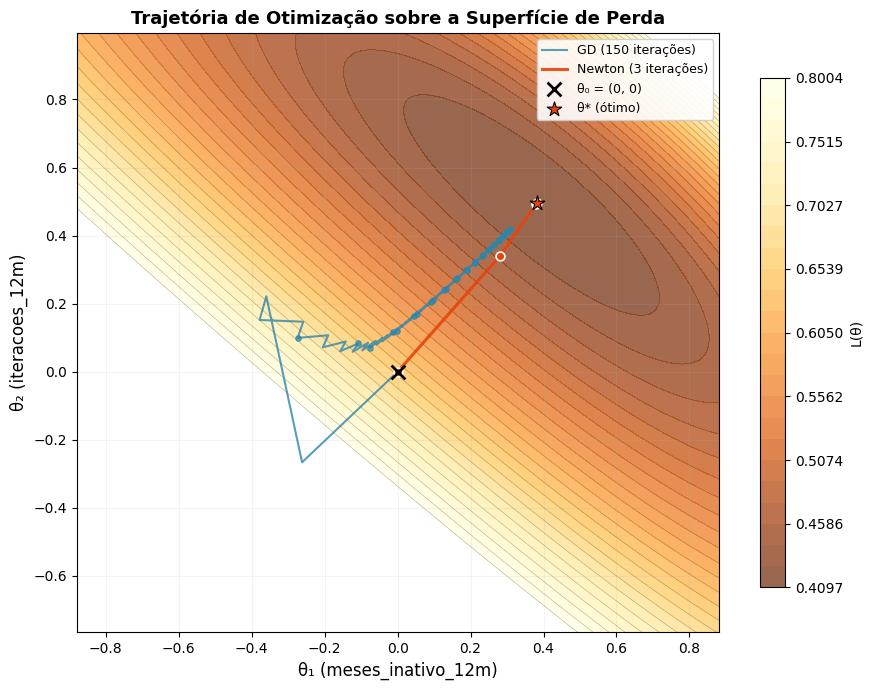

In [144]:
# === Trajetória 2D: GD vs Newton sobre curvas de nível ===
# Selecionar as 2 features com maior |θ| no modelo Newton treinado
coef_abs = np.abs(modelo_newton.w[1:])  # exclui bias
top2_idx = np.argsort(coef_abs)[-2:]
feat_names_2d = [list(X_train.columns)[i] for i in top2_idx]
print(f"Features selecionadas: {feat_names_2d}")

X_2d_train = np.array(X_train, dtype=float)[:, top2_idx]
y_2d = np.array(y_train, dtype=float)

# Função para simular otimização e guardar trajetória
def simular_trajetoria(metodo_otim, X, y, lam=0.01, tmax=200, tol=1e-4):
    """Roda o otimizador manualmente e retorna lista de [w0, w1, w2] a cada iteração."""
    X_b = np.c_[np.ones(X.shape[0], dtype=float), np.asarray(X, dtype=float)]
    w = np.zeros(X_b.shape[1], dtype=float)
    trajetoria = [w.copy()]

    for _ in range(tmax):
        grad = RegressaoLogistica._gradiente(w, X_b, y, lam)
        norma = float(np.linalg.norm(grad))
        if norma < tol:
            break

        if metodo_otim == 'newton':
            H = np.asarray(RegressaoLogistica._hessiana(w, X_b, lam), dtype=float)
            H_reg = H + 1e-8 * np.eye(H.shape[0])
            try:
                direcao = np.linalg.solve(H_reg, -np.asarray(grad, dtype=float))
            except np.linalg.LinAlgError:
                direcao = -grad
        else:
            direcao = -grad

        g = lambda a: RegressaoLogistica._funcao_perda(w + a * direcao, X_b, y, lam)
        a0_, b0_ = RegressaoLogistica._intervalo_inicial(g)
        alpha = RegressaoLogistica._busca_secao_aurea(g, a0_, b0_)
        w = w + alpha * direcao
        trajetoria.append(w.copy())

    return np.array(trajetoria)

traj_gd = simular_trajetoria('gd', X_2d_train, y_2d, tmax=150)
traj_nt = simular_trajetoria('newton', X_2d_train, y_2d)

# Grade para curvas de nível (usando θ₁ e θ₂, fixando bias no valor ótimo do Newton)
bias_otimo = traj_nt[-1, 0]
X_2d_b = np.c_[np.ones(X_2d_train.shape[0], dtype=float), np.asarray(X_2d_train, dtype=float)]

margem = 0.5
t1_min = min(traj_gd[:, 1].min(), traj_nt[:, 1].min()) - margem
t1_max = max(traj_gd[:, 1].max(), traj_nt[:, 1].max()) + margem
t2_min = min(traj_gd[:, 2].min(), traj_nt[:, 2].min()) - margem
t2_max = max(traj_gd[:, 2].max(), traj_nt[:, 2].max()) + margem

t1_grid = np.linspace(t1_min, t1_max, 120)
t2_grid = np.linspace(t2_min, t2_max, 120)
T1, T2 = np.meshgrid(t1_grid, t2_grid)
Z = np.zeros_like(T1)

for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        w_test = np.array([bias_otimo, T1[i, j], T2[i, j]], dtype=float)
        Z[i, j] = RegressaoLogistica._funcao_perda(w_test, X_2d_b, y_2d, 0.01)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 7))

# Curvas de nível
niveis = np.linspace(Z.min(), Z.min() + (Z.max() - Z.min()) * 0.4, 25)
contour = ax.contourf(T1, T2, Z, levels=niveis, cmap='YlOrBr_r', alpha=0.7)
ax.contour(T1, T2, Z, levels=niveis, colors='#8B7355', linewidths=0.4, alpha=0.6)
plt.colorbar(contour, ax=ax, label='L(θ)', shrink=0.85)

# Trajetória GD
ax.plot(traj_gd[:, 1], traj_gd[:, 2], color='#2E86AB', linewidth=1.5, alpha=0.8,
        label=f'GD ({len(traj_gd)-1} iterações)', zorder=3)
ax.scatter(traj_gd[::5, 1], traj_gd[::5, 2], color='#2E86AB', s=15, zorder=4, alpha=0.7)

# Trajetória Newton
ax.plot(traj_nt[:, 1], traj_nt[:, 2], color='#E8430C', linewidth=2.2, alpha=0.9,
        label=f'Newton ({len(traj_nt)-1} iterações)', zorder=5)
ax.scatter(traj_nt[:, 1], traj_nt[:, 2], color='#E8430C', s=40, zorder=6,
           edgecolors='white', linewidths=1.2)

# Ponto inicial e final
ax.scatter([0], [0], color='black', s=100, marker='x', linewidths=2,
           label='θ₀ = (0, 0)', zorder=7)
ax.scatter([traj_nt[-1, 1]], [traj_nt[-1, 2]], color='#E8430C', s=120, marker='*',
           edgecolors='black', linewidths=0.8, label='θ* (ótimo)', zorder=7)

ax.set_xlabel(f'θ₁ ({feat_names_2d[0]})', fontsize=12)
ax.set_ylabel(f'θ₂ ({feat_names_2d[1]})', fontsize=12)
ax.set_title('Trajetória de Otimização sobre a Superfície de Perda',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

## 8.5.1 Com balanceamento

Features selecionadas: ['salario_anual_menos que $40K', 'estado_civil_solteiro']


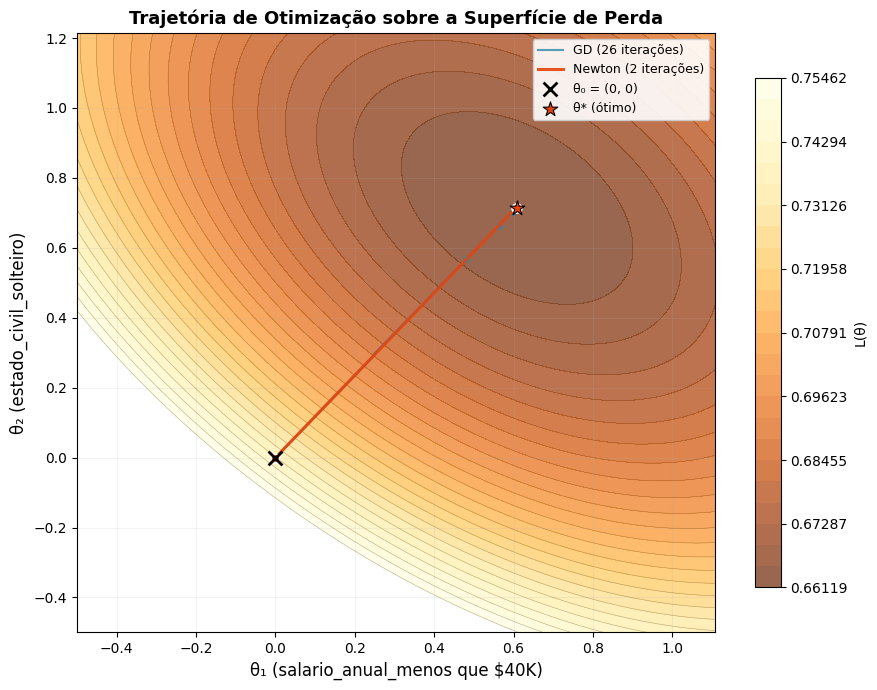

In [145]:
coef_abs = np.abs(modelo_newton_balanced.w[1:])  # exclui bias
top2_idx = np.argsort(coef_abs)[-2:]
feat_names_2d = [list(X_res.columns)[i] for i in top2_idx]
print(f"Features selecionadas: {feat_names_2d}")

X_2d_train = np.array(X_res, dtype=float)[:, top2_idx]
y_2d = np.array(y_res, dtype=float)

# Função para simular otimização e guardar trajetória
def simular_trajetoria(metodo_otim, X, y, lam=0.01, tmax=200, tol=1e-4):
    """Roda o otimizador manualmente e retorna lista de [w0, w1, w2] a cada iteração."""
    X_b = np.c_[np.ones(X.shape[0], dtype=float), np.asarray(X, dtype=float)] 
    w = np.zeros(X_b.shape[1], dtype=float)
    trajetoria = [w.copy()]

    for _ in range(tmax):
        grad = RegressaoLogistica._gradiente(w, X_b, y, lam)
        norma = float(np.linalg.norm(grad))
        if norma < tol:
            break

        if metodo_otim == 'newton':
            H = np.asarray(RegressaoLogistica._hessiana(w, X_b, lam), dtype=float)
            H_reg = H + 1e-8 * np.eye(H.shape[0])
            try:
                direcao = np.linalg.solve(H_reg, -np.asarray(grad, dtype=float))
            except np.linalg.LinAlgError:
                direcao = -grad
        else:
            direcao = -grad

        g = lambda a: RegressaoLogistica._funcao_perda(w + a * direcao, X_b, y, lam)
        a0_, b0_ = RegressaoLogistica._intervalo_inicial(g)
        alpha = RegressaoLogistica._busca_secao_aurea(g, a0_, b0_)
        w = w + alpha * direcao
        trajetoria.append(w.copy())

    return np.array(trajetoria)

traj_gd = simular_trajetoria('gd', X_2d_train, y_2d, tmax=150)
traj_nt = simular_trajetoria('newton', X_2d_train, y_2d)

# Grade para curvas de nível (usando θ₁ e θ₂, fixando bias no valor ótimo do Newton)
bias_otimo = traj_nt[-1, 0]
X_2d_b = np.c_[np.ones(X_2d_train.shape[0], dtype=float), np.asarray(X_2d_train, dtype=float)]

margem = 0.5
t1_min = min(traj_gd[:, 1].min(), traj_nt[:, 1].min()) - margem
t1_max = max(traj_gd[:, 1].max(), traj_nt[:, 1].max()) + margem
t2_min = min(traj_gd[:, 2].min(), traj_nt[:, 2].min()) - margem
t2_max = max(traj_gd[:, 2].max(), traj_nt[:, 2].max()) + margem

t1_grid = np.linspace(t1_min, t1_max, 120)
t2_grid = np.linspace(t2_min, t2_max, 120)
T1, T2 = np.meshgrid(t1_grid, t2_grid)
Z = np.zeros_like(T1)

for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        w_test = np.array([bias_otimo, T1[i, j], T2[i, j]], dtype=float)
        Z[i, j] = RegressaoLogistica._funcao_perda(w_test, X_2d_b, y_2d, 0.01)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(9, 7))

# Curvas de nível
niveis = np.linspace(Z.min(), Z.min() + (Z.max() - Z.min()) * 0.4, 25)
contour = ax.contourf(T1, T2, Z, levels=niveis, cmap='YlOrBr_r', alpha=0.7)
ax.contour(T1, T2, Z, levels=niveis, colors='#8B7355', linewidths=0.4, alpha=0.6)
plt.colorbar(contour, ax=ax, label='L(θ)', shrink=0.85)

# Trajetória GD
ax.plot(traj_gd[:, 1], traj_gd[:, 2], color='#2E86AB', linewidth=1.5, alpha=0.8,
        label=f'GD ({len(traj_gd)-1} iterações)', zorder=3)
ax.scatter(traj_gd[::5, 1], traj_gd[::5, 2], color='#2E86AB', s=15, zorder=4, alpha=0.7)

# Trajetória Newton
ax.plot(traj_nt[:, 1], traj_nt[:, 2], color='#E8430C', linewidth=2.2, alpha=0.9,
        label=f'Newton ({len(traj_nt)-1} iterações)', zorder=5)
ax.scatter(traj_nt[:, 1], traj_nt[:, 2], color='#E8430C', s=40, zorder=6,
           edgecolors='white', linewidths=1.2)

# Ponto inicial e final
ax.scatter([0], [0], color='black', s=100, marker='x', linewidths=2,
           label='θ₀ = (0, 0)', zorder=7)
ax.scatter([traj_nt[-1, 1]], [traj_nt[-1, 2]], color='#E8430C', s=120, marker='*',
           edgecolors='black', linewidths=0.8, label='θ* (ótimo)', zorder=7)

ax.set_xlabel(f'θ₁ ({feat_names_2d[0]})', fontsize=12)
ax.set_ylabel(f'θ₂ ({feat_names_2d[1]})', fontsize=12)
ax.set_title('Trajetória de Otimização sobre a Superfície de Perda',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

### Interpretação

**Curvas de nível:** cada linha representa pontos com o mesmo valor de $L(\theta)$. Regiões mais claras indicam perda menor (mais próximas do mínimo).

**Trajetória do Gradiente Descendente (azul):** caminha com muitos passos pequenos, seguindo a direção de maior declive local $d = -\nabla L(\theta)$. Pode apresentar zigue-zague quando as curvas de nível são elípticas (diferentes curvaturas nos eixos).

**Trajetória do Método de Newton (vermelho):** chega ao mínimo em poucos passos, pois a direção $d = -H^{-1}\nabla L$ corrige a escala do gradiente pela curvatura local — cada passo aponta mais diretamente ao ótimo.

> **Conexão com a teoria (Aula 07/08):** ambos seguem o modelo geral de descida $\theta_{k+1} = \theta_k + \alpha^* d_k$, diferindo apenas na escolha de $d_k$. O passo $\alpha^*$ é determinado pela busca em linha (seção áurea), garantindo a maior redução possível de $L$ em cada direção escolhida.

---
## 9. Avaliação no Conjunto de Teste

Avaliamos o modelo treinado pelo Método de Newton (solução mais precisa) no conjunto de teste.

Acurácia             0.8667
Precisão             0.6536
Recall               0.3600
F1-score             0.4643
AUC-ROC              0.8857


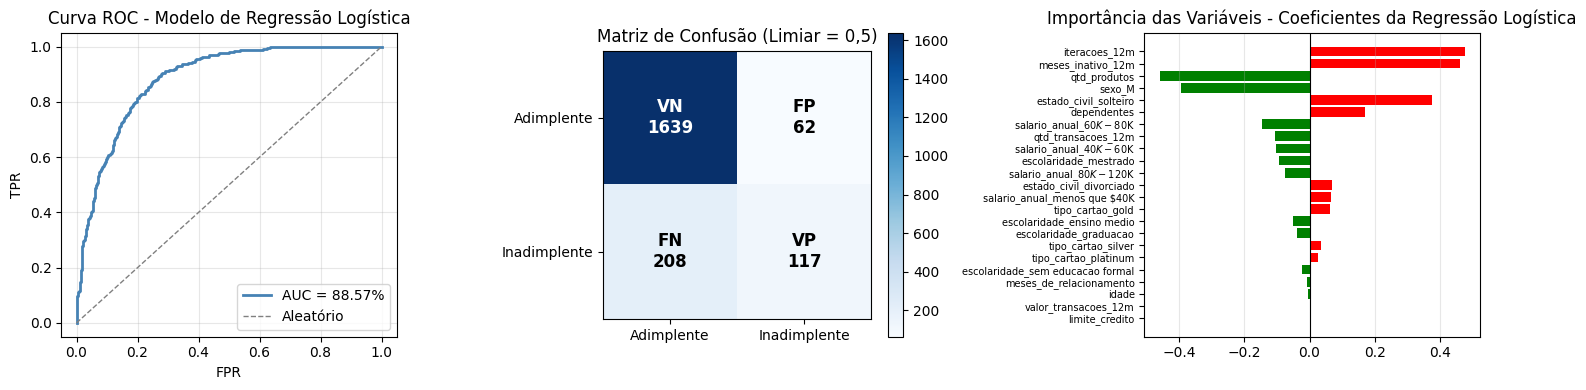

In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

y_pred = modelo_newton.predict(X_test)
prob   = modelo_newton.predict_prob(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, prob)

print("=" * 40)
print(f"{'Acurácia':<20} {acc:.4f}")
print(f"{'Precisão':<20} {prec:.4f}")
print(f"{'Recall':<20} {rec:.4f}")
print(f"{'F1-score':<20} {f1:.4f}")
print(f"{'AUC-ROC':<20} {auc:.4f}")
print("=" * 40)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
taxas_fp, taxas_vp, _ = roc_curve(y_test, prob)
axes[0].plot(taxas_fp, taxas_vp, color='steelblue', linewidth=2, label=f'AUC = {auc*100:.2f}%')
axes[0].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1, label='Aleatório')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC - Modelo de Regressão Logística'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
VN, FP, FN, VP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
valores = np.array([[VN, FP], [FN, VP]])
rotulos = [['VN','FP'],['FN','VP']]
im = axes[1].imshow(valores, cmap='Blues')
for i in range(2):
    for j in range(2):
        cor = 'white' if valores[i,j] > valores.max()/2 else 'black'
        axes[1].text(j, i, f'{rotulos[i][j]}\n{valores[i,j]}', ha='center', va='center',
                     fontsize=12, fontweight='bold', color=cor)
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Adimplente','Inadimplente']); axes[1].set_yticklabels(['Adimplente','Inadimplente'])
axes[1].set_title('Matriz de Confusão (Limiar = 0,5)'); plt.colorbar(im, ax=axes[1])

# Coeficientes
coef = modelo_newton.w[1:]
nomes_features = list(X_train.columns)
idx  = np.argsort(np.abs(coef))
cores = ['green' if v < 0 else 'red' for v in coef[idx]]
axes[2].barh(range(len(coef)), coef[idx], color=cores)
axes[2].set_yticks(range(len(coef)))
axes[2].set_yticklabels([nomes_features[i] for i in idx], fontsize=7)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Importância das Variáveis - Coeficientes da Regressão Logística'); axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

## 9.1 Com balanceamento

Acurácia             0.8317
Precisão             0.4828
Recall               0.6892
F1-score             0.5678
AUC-ROC              0.8776


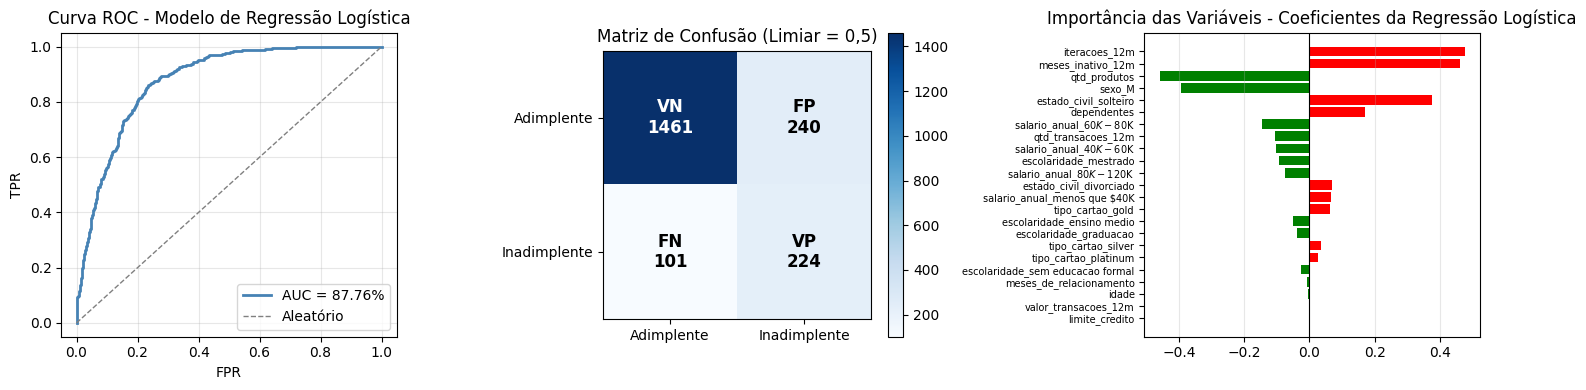

In [147]:
y_pred = modelo_newton_balanced.predict(X_test)
prob   = modelo_newton_balanced.predict_prob(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, prob)

print("=" * 40)
print(f"{'Acurácia':<20} {acc:.4f}")
print(f"{'Precisão':<20} {prec:.4f}")
print(f"{'Recall':<20} {rec:.4f}")
print(f"{'F1-score':<20} {f1:.4f}")
print(f"{'AUC-ROC':<20} {auc:.4f}")
print("=" * 40)

# Gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC
taxas_fp, taxas_vp, _ = roc_curve(y_test, prob)
axes[0].plot(taxas_fp, taxas_vp, color='steelblue', linewidth=2, label=f'AUC = {auc*100:.2f}%')
axes[0].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1, label='Aleatório')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC - Modelo de Regressão Logística'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
VN, FP, FN, VP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
valores = np.array([[VN, FP], [FN, VP]])
rotulos = [['VN','FP'],['FN','VP']]
im = axes[1].imshow(valores, cmap='Blues')
for i in range(2):
    for j in range(2):
        cor = 'white' if valores[i,j] > valores.max()/2 else 'black'
        axes[1].text(j, i, f'{rotulos[i][j]}\n{valores[i,j]}', ha='center', va='center',
                     fontsize=12, fontweight='bold', color=cor)
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Adimplente','Inadimplente']); axes[1].set_yticklabels(['Adimplente','Inadimplente'])
axes[1].set_title('Matriz de Confusão (Limiar = 0,5)'); plt.colorbar(im, ax=axes[1])

# Coeficientes
coef = modelo_newton.w[1:]
nomes_features = list(X_train.columns)
idx  = np.argsort(np.abs(coef))
cores = ['green' if v < 0 else 'red' for v in coef[idx]]
axes[2].barh(range(len(coef)), coef[idx], color=cores)
axes[2].set_yticks(range(len(coef)))
axes[2].set_yticklabels([nomes_features[i] for i in idx], fontsize=7)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Importância das Variáveis - Coeficientes da Regressão Logística'); axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout(); plt.show()

### 9.2 Análise Detalhada de Classificação

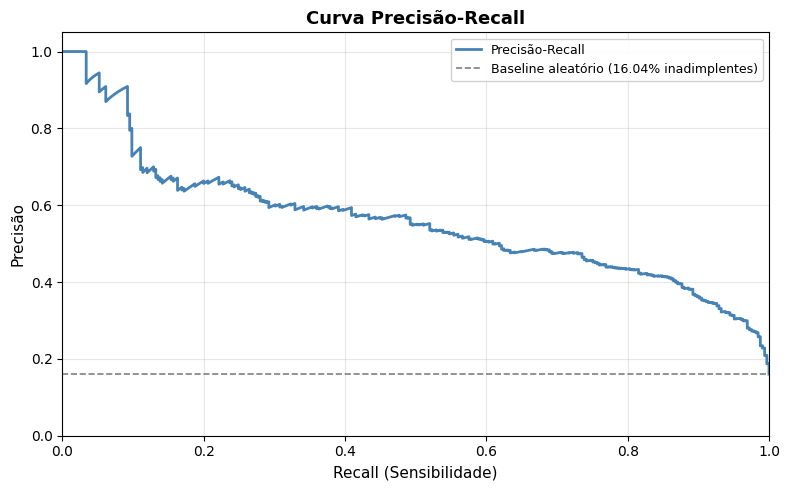

In [148]:
# === Gráfico 9: Curva Precisão-Recall ===
from sklearn.metrics import precision_recall_curve

y_prob_pr = modelo_newton_balanced.predict_prob(X_test)
y_test_np = np.array(y_test, dtype=float)

precisao, recall, limiares_pr = precision_recall_curve(y_test_np, y_prob_pr)
proporcao_inadimplentes = y_test_np.mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(recall, precisao, color='steelblue', linewidth=2, label='Precisão-Recall')
ax.axhline(proporcao_inadimplentes, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline aleatório ({proporcao_inadimplentes:.2%} inadimplentes)')

ax.set_xlabel('Recall (Sensibilidade)', fontsize=11)
ax.set_ylabel('Precisão', fontsize=11)
ax.set_title('Curva Precisão-Recall', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()


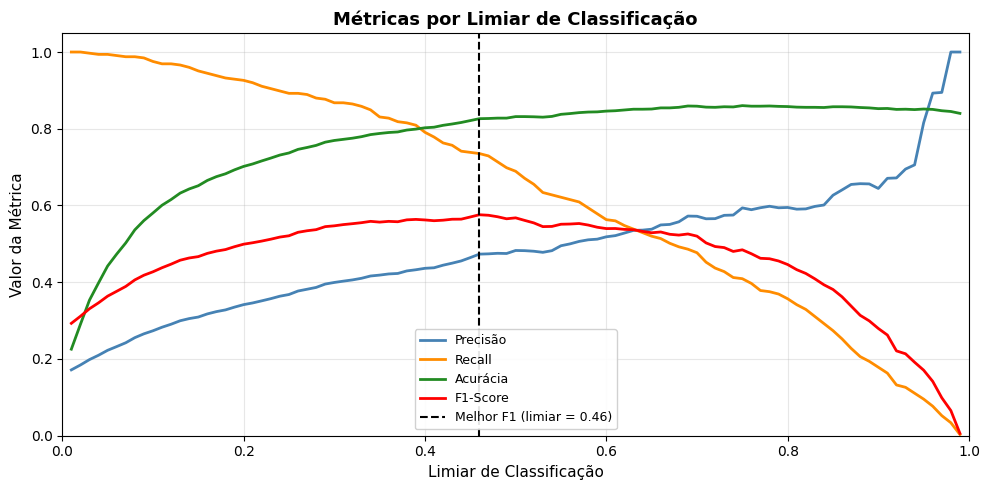

Limiar que maximiza F1: 0.46
F1-Score máximo:        0.5759
Precisão nesse limiar:  0.4733
Recall nesse limiar:    0.7354


In [149]:
# === Gráfico 10: Métricas por Limiar de Classificação ===
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

limiares_loop = np.arange(0.01, 1.00, 0.01)
precisoes_loop  = []
recalls_loop    = []
acuracias_loop  = []
f1s_loop        = []

y_test_np2 = np.array(y_test, dtype=float)
y_prob_loop = modelo_newton_balanced.predict_prob(X_test)

for limiar in limiares_loop:
    y_pred_limiar = (y_prob_loop >= limiar).astype(float)
    precisoes_loop.append(precision_score(y_test_np2, y_pred_limiar, zero_division=0))
    recalls_loop.append(recall_score(y_test_np2, y_pred_limiar, zero_division=0))
    acuracias_loop.append(accuracy_score(y_test_np2, y_pred_limiar))
    f1s_loop.append(f1_score(y_test_np2, y_pred_limiar, zero_division=0))

idx_melhor_f1 = int(np.argmax(f1s_loop))
limiar_melhor_f1 = limiares_loop[idx_melhor_f1]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(limiares_loop, precisoes_loop,  color='steelblue',   linewidth=2, label='Precisão')
ax.plot(limiares_loop, recalls_loop,    color='darkorange',  linewidth=2, label='Recall')
ax.plot(limiares_loop, acuracias_loop,  color='forestgreen', linewidth=2, label='Acurácia')
ax.plot(limiares_loop, f1s_loop,        color='red',         linewidth=2, label='F1-Score')

ax.axvline(limiar_melhor_f1, color='black', linestyle='--', linewidth=1.5,
           label=f'Melhor F1 (limiar = {limiar_melhor_f1:.2f})')

ax.set_xlabel('Limiar de Classificação', fontsize=11)
ax.set_ylabel('Valor da Métrica', fontsize=11)
ax.set_title('Métricas por Limiar de Classificação', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print(f"Limiar que maximiza F1: {limiar_melhor_f1:.2f}")
print(f"F1-Score máximo:        {f1s_loop[idx_melhor_f1]:.4f}")
print(f"Precisão nesse limiar:  {precisoes_loop[idx_melhor_f1]:.4f}")
print(f"Recall nesse limiar:    {recalls_loop[idx_melhor_f1]:.4f}")


### Interpretação

**Gráfico 9 — Curva Precisão-Recall:** mostra o balanço entre precisão e recall ao variar o limiar de classificação. A linha tracejada representa um classificador aleatório (baseline), que atingiria precisão igual à proporção de inadimplentes no conjunto de teste. Quanto maior a área sob a curva (AUC-PR), melhor o modelo para identificar inadimplentes.

**Gráfico 10 — Métricas por Limiar:** ao variar o limiar de 0 a 1, observa-se o clássico trade-off precisão-recall: aumentar o recall (detectar mais inadimplentes) reduz a precisão (mais falsos positivos). O ponto de maior F1-Score (linha tracejada) representa o limiar que equilibra melhor precisão e recall para este conjunto de dados.

> **Aplicação prática:** em contexto bancário, o custo de não detectar um inadimplente (falso negativo) costuma ser maior do que o custo de negar crédito a um adimplente (falso positivo). Dependendo do custo de cada tipo de erro, pode ser vantajoso usar um limiar menor que 0,5 para aumentar o recall.

---
### 9.1 Distribuição das Probabilidades Preditas

O histograma abaixo mostra como o modelo distribui $P(y=1|x)$ para cada classe real. Um bom classificador concentra inadimplentes ($y=1$) próximos de 1 e adimplentes ($y=0$) próximos de 0, com **pouca sobreposição** entre as distribuições.

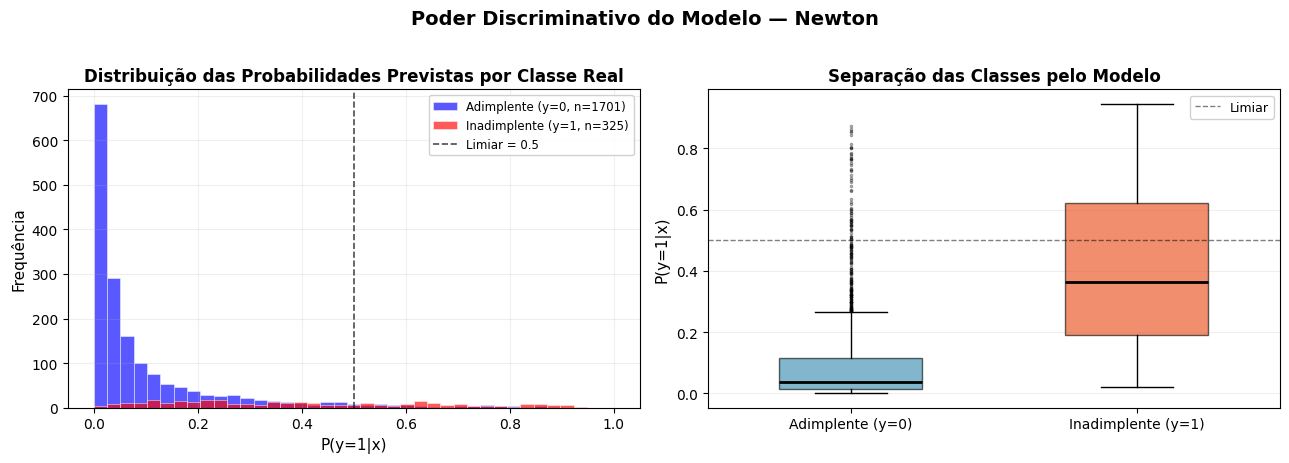

Mediana P(y=1|x) para adimplentes:   0.0383
Mediana P(y=1|x) para inadimplentes: 0.3646
Separação das medianas:              0.3263


In [150]:
# === Distribuição de probabilidades preditas por classe ===
prob_teste = modelo_newton.predict_prob(X_test)
y_teste_np = np.array(y_test, dtype=float)

prob_classe_0 = prob_teste[y_teste_np == 0]
prob_classe_1 = prob_teste[y_teste_np == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Histograma sobreposto ---
bins = np.linspace(0, 1, 40)
axes[0].hist(prob_classe_0, bins=bins, color='blue', alpha=0.65,
             label=f'Adimplente (y=0, n={len(prob_classe_0)})', edgecolor='white', linewidth=0.5)
axes[0].hist(prob_classe_1, bins=bins, color='red', alpha=0.65,
             label=f'Inadimplente (y=1, n={len(prob_classe_1)})', edgecolor='white', linewidth=0.5)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Limiar = 0.5')
axes[0].set_xlabel('P(y=1|x)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição das Probabilidades Previstas por Classe Real', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5, framealpha=0.9)
axes[0].grid(True, alpha=0.2)

# --- Box plot lado a lado ---
bp = axes[1].boxplot([prob_classe_0, prob_classe_1],
                     labels=['Adimplente (y=0)', 'Inadimplente (y=1)'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#E8430C')
bp['boxes'][1].set_alpha(0.6)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Limiar')
axes[1].set_ylabel('P(y=1|x)', fontsize=11)
axes[1].set_title('Separação das Classes pelo Modelo', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, axis='y', alpha=0.2)

fig.suptitle('Poder Discriminativo do Modelo — Newton',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estatísticas de separação
print(f"Mediana P(y=1|x) para adimplentes:   {np.median(prob_classe_0):.4f}")
print(f"Mediana P(y=1|x) para inadimplentes: {np.median(prob_classe_1):.4f}")
print(f"Separação das medianas:              {np.median(prob_classe_1) - np.median(prob_classe_0):.4f}")

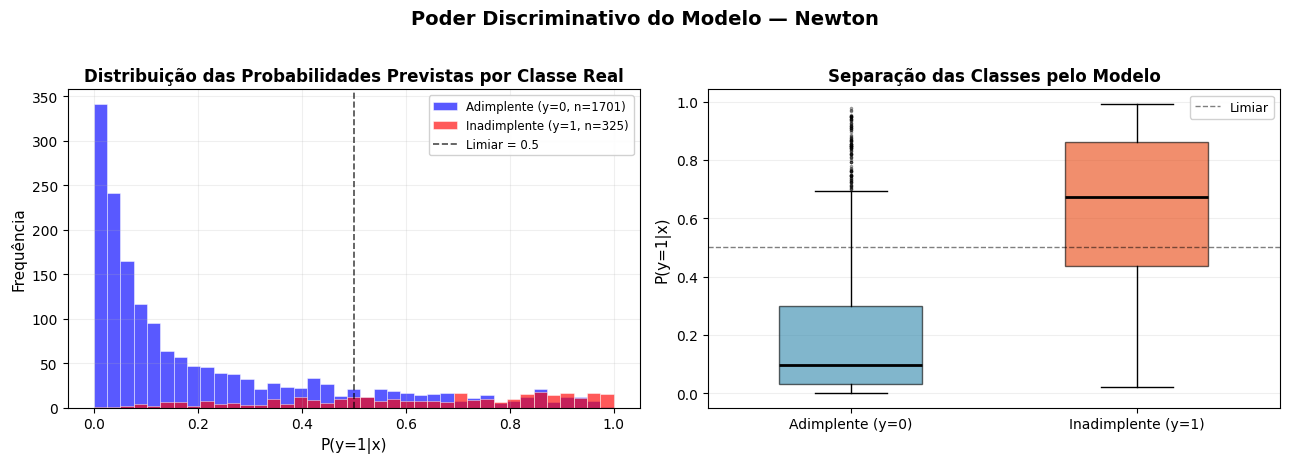

Mediana P(y=1|x) para adimplentes:   0.0982
Mediana P(y=1|x) para inadimplentes: 0.6715
Separação das medianas:              0.5733


In [151]:
prob_teste = modelo_newton_balanced.predict_prob(X_test)
y_teste_np = np.array(y_test, dtype=float)

prob_classe_0 = prob_teste[y_teste_np == 0]
prob_classe_1 = prob_teste[y_teste_np == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Histograma sobreposto ---
bins = np.linspace(0, 1, 40)
axes[0].hist(prob_classe_0, bins=bins, color='blue', alpha=0.65,
             label=f'Adimplente (y=0, n={len(prob_classe_0)})', edgecolor='white', linewidth=0.5)
axes[0].hist(prob_classe_1, bins=bins, color='red', alpha=0.65,
             label=f'Inadimplente (y=1, n={len(prob_classe_1)})', edgecolor='white', linewidth=0.5)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label='Limiar = 0.5')
axes[0].set_xlabel('P(y=1|x)', fontsize=11)
axes[0].set_ylabel('Frequência', fontsize=11)
axes[0].set_title('Distribuição das Probabilidades Previstas por Classe Real', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8.5, framealpha=0.9)
axes[0].grid(True, alpha=0.2)

# --- Box plot lado a lado ---
bp = axes[1].boxplot([prob_classe_0, prob_classe_1],
                     labels=['Adimplente (y=0)', 'Inadimplente (y=1)'],
                     patch_artist=True, widths=0.5,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='.', markersize=3, alpha=0.4))
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#E8430C')
bp['boxes'][1].set_alpha(0.6)
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Limiar')
axes[1].set_ylabel('P(y=1|x)', fontsize=11)
axes[1].set_title('Separação das Classes pelo Modelo', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, axis='y', alpha=0.2)

fig.suptitle('Poder Discriminativo do Modelo — Newton',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Estatísticas de separação
print(f"Mediana P(y=1|x) para adimplentes:   {np.median(prob_classe_0):.4f}")
print(f"Mediana P(y=1|x) para inadimplentes: {np.median(prob_classe_1):.4f}")
print(f"Separação das medianas:              {np.median(prob_classe_1) - np.median(prob_classe_0):.4f}")

### Interpretação

**Histograma (esquerda):** mostra a distribuição de $P(y=1|x)$ para cada classe real. Um modelo com bom poder discriminativo separa as duas distribuições com pouca sobreposição — adimplentes ($y=0$) concentrados perto de 0 e inadimplentes ($y=1$) concentrados perto de 1.

**Box plot (direita):** resume a separação entre as classes. Quanto maior a distância entre as medianas e menor a sobreposição dos bigodes, melhor a capacidade do modelo de distinguir as classes.

> **O limiar de 0.5** (linha tracejada) define a fronteira de decisão: exemplos com $P(y=1|x) \geq 0.5$ são classificados como inadimplentes. A região de sobreposição entre as distribuições é onde ocorrem os erros de classificação (falsos positivos e falsos negativos).